## The Electronic Nose Dataset for Plant Oil with Different Compositions

In [14]:
import os
import pandas as pd
from pathlib import Path

# Define the dataset path
dataset_path = Path('/Users/momthu/Documents/duhoc/Hungary/elte/research/oil/dataset_Oils')

# Get all oil type folders
oil_folders = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
print(f"Found {len(oil_folders)} oil type folders:")
for folder in oil_folders:
    print(f"  - {folder.name}")


Found 19 oil type folders:
  - CO
  - COO
  - COO1
  - COO2
  - COO3
  - COO4
  - COO5
  - RO0
  - RO1
  - RO2
  - RO3
  - RO4
  - RO5
  - SO0
  - SO1
  - SO2
  - SO3
  - SO4
  - SO5


In [15]:
# Check columns consistency across all files
columns_dict = {}
total_files = 0
files_with_issues = []

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    print(f"\n{oil_folder.name}: {len(txt_files)} files")
    
    if txt_files:
        # Read first file to get columns
        first_file = txt_files[0]
        df = pd.read_csv(first_file)
        columns = tuple(df.columns)
        
        if columns not in columns_dict:
            columns_dict[columns] = []
        
        columns_dict[columns].append((oil_folder.name, first_file.name, len(txt_files)))
        print(f"  Columns: {list(df.columns)}")
        print(f"  Shape: {df.shape}")
        total_files += len(txt_files)
        
        # Check if all files in this folder have the same columns
        for txt_file in txt_files[1:]:
            df_check = pd.read_csv(txt_file)
            if tuple(df_check.columns) != columns:
                files_with_issues.append((oil_folder.name, txt_file.name))

print(f"\n{'='*60}")
print(f"TOTAL FILES: {total_files}")
print(f"{'='*60}")


CO: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO1: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO2: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO3: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO4: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO5: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

RO0: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

RO1: 70 fil

In [16]:
# Summary of columns consistency
print("\n" + "="*70)
print("SUMMARY OF COLUMN CONSISTENCY ANALYSIS")
print("="*70)

if len(columns_dict) == 1:
    print("\n✓ ALL FILES HAVE CONSISTENT COLUMNS!")
    print(f"\nTotal unique column structure(s): {len(columns_dict)}")
    
    # Display the single column structure
    for columns, oil_info in columns_dict.items():
        print(f"\nColumn names ({len(columns)} columns):")
        for i, col in enumerate(columns, 1):
            print(f"  {i}. {col}")
        
        print(f"\nFiles using this structure ({len(oil_info)} oil types):")
        total_files_with_structure = 0
        for oil_type, first_file, num_files in oil_info:
            print(f"  - {oil_type}: {num_files} files")
            total_files_with_structure += num_files
        print(f"\n  Total files: {total_files_with_structure}")
else:
    print(f"\n✗ FOUND {len(columns_dict)} DIFFERENT COLUMN STRUCTURES!")
    print("\nColumn structures:")
    for i, (columns, oil_info) in enumerate(columns_dict.items(), 1):
        print(f"\n  Structure {i}: {columns}")
        print(f"  Used in: {[info[0] for info in oil_info]}")

if files_with_issues:
    print(f"\n⚠ WARNING: Found {len(files_with_issues)} files with inconsistent columns")
    print("Files with issues:")
    for oil_type, filename in files_with_issues[:10]:  # Show first 10
        print(f"  - {oil_type}/{filename}")
    if len(files_with_issues) > 10:
        print(f"  ... and {len(files_with_issues) - 10} more")
else:
    print("\n✓ All files within each oil type have consistent columns")

print("\n" + "="*70)


SUMMARY OF COLUMN CONSISTENCY ANALYSIS

✓ ALL FILES HAVE CONSISTENT COLUMNS!

Total unique column structure(s): 1

Column names (7 columns):
  1. Time [s]
  2. TGS2620
  3. TGS2602
  4. TGS2603
  5. TGS2610
  6. TGS2611
  7. TGS2600

Files using this structure (19 oil types):
  - CO: 70 files
  - COO: 70 files
  - COO1: 70 files
  - COO2: 70 files
  - COO3: 70 files
  - COO4: 70 files
  - COO5: 70 files
  - RO0: 70 files
  - RO1: 70 files
  - RO2: 70 files
  - RO3: 70 files
  - RO4: 70 files
  - RO5: 70 files
  - SO0: 70 files
  - SO1: 70 files
  - SO2: 70 files
  - SO3: 70 files
  - SO4: 70 files
  - SO5: 70 files

  Total files: 1330

✓ All files within each oil type have consistent columns



In [17]:
# Additional details about data structure
print("\nDATA STRUCTURE DETAILS:")
print("="*70)

# Check data shape consistency
print("\nChecking data shape consistency...")
shape_dict = {}

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    if txt_files:
        df_sample = pd.read_csv(txt_files[0])
        shape = df_sample.shape
        
        if shape not in shape_dict:
            shape_dict[shape] = []
        shape_dict[shape].append(oil_folder.name)

print(f"\nFound {len(shape_dict)} unique data shape(s):")
for shape, oil_types in sorted(shape_dict.items()):
    print(f"  Shape {shape}: {len(oil_types)} oil types")
    if len(oil_types) <= 5:
        print(f"    Oil types: {', '.join(oil_types)}")

# Data type information
print("\nData type information:")
sample_df = pd.read_csv(list(oil_folders[0].glob('*.txt'))[0])
print(sample_df.dtypes)

print("\nSample data (first 5 rows from CO_1.txt):")
print(sample_df.head())


DATA STRUCTURE DETAILS:

Checking data shape consistency...

Found 1 unique data shape(s):
  Shape (150, 7): 19 oil types

Data type information:
Time [s]      int64
TGS2620     float64
TGS2602     float64
TGS2603     float64
TGS2610     float64
TGS2611     float64
TGS2600     float64
dtype: object

Sample data (first 5 rows from CO_1.txt):
   Time [s]   TGS2620   TGS2602   TGS2603   TGS2610   TGS2611   TGS2600
0         1  0.044517  0.030207  0.029896  0.008595  0.018460  0.033513
1         2  0.044510  0.030220  0.029909  0.008594  0.018462  0.033507
2         3  0.044500  0.030234  0.029908  0.008592  0.018458  0.033500
3         4  0.044494  0.030246  0.029910  0.008594  0.018458  0.033490
4         5  0.044485  0.030262  0.029915  0.008593  0.018457  0.033486


## Analysis Results

### Key Findings ✓

1. **Column Standardization: FULLY STANDARDIZED**
   - All 1,330 data files across all 19 oil types use identical columns
   - No inconsistencies found

2. **Column Structure**
   - **7 columns total**: 1 time column + 6 sensor columns
   - Time column: `Time [s]` (integer values, 1-150 seconds)
   - Sensor columns: `TGS2620`, `TGS2602`, `TGS2603`, `TGS2610`, `TGS2611`, `TGS2600` (all float values)

3. **Data Shape Consistency**
   - All files have identical dimensions: **(150 rows, 7 columns)**
   - Each file contains 150 time measurements

4. **Oil Types**
   - 19 different oil types represented
   - Each type has exactly 70 data files
   - Oil types: CO, COO, COO1-5, RO0-5, SO0-5

### Sensor Information
The dataset uses 6 sensors from the TGS series (electronic nose sensors):
- TGS2620: TVOC & smoke detection
- TGS2602: Odor & smoke detection  
- TGS2603: Odor detection
- TGS2610: Alcohol detection
- TGS2611: General air quality
- TGS2600: General air quality

In [18]:
# Statistics about sample counts in each file
print("\n" + "="*70)
print("SAMPLE COUNT STATISTICS")
print("="*70)

file_stats = []

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    
    if txt_files:
        for txt_file in txt_files:
            df = pd.read_csv(txt_file)
            sample_count = len(df)
            file_stats.append({
                'Oil Type': oil_folder.name,
                'File': txt_file.name,
                'Samples': sample_count,
                'Path': str(txt_file)
            })

# Create dataframe for easier analysis
stats_df = pd.DataFrame(file_stats)

# Summary statistics
print("\nOVERALL STATISTICS:")
print(f"  Total files: {len(stats_df)}")
print(f"  Total samples across all files: {stats_df['Samples'].sum():,}")
print(f"  Average samples per file: {stats_df['Samples'].mean():.0f}")
print(f"  Min samples in a file: {stats_df['Samples'].min()}")
print(f"  Max samples in a file: {stats_df['Samples'].max()}")

# By oil type
print("\nSAMPLES BY OIL TYPE:")
oil_type_stats = stats_df.groupby('Oil Type').agg({
    'Samples': ['count', 'sum', 'mean', 'min', 'max']
}).round(0)

for oil_type in sorted(stats_df['Oil Type'].unique()):
    subset = stats_df[stats_df['Oil Type'] == oil_type]
    print(f"\n  {oil_type}:")
    print(f"    Files: {len(subset)}")
    print(f"    Total samples: {subset['Samples'].sum():,}")
    print(f"    Samples per file: {subset['Samples'].iloc[0]} (all files identical)")

# Check if all files have same number of samples
unique_samples = stats_df['Samples'].unique()
if len(unique_samples) == 1:
    print(f"\n✓ ALL FILES HAVE SAME NUMBER OF SAMPLES: {unique_samples[0]} samples per file")
else:
    print(f"\n⚠ Files have DIFFERENT sample counts:")
    for sample_count in sorted(unique_samples):
        count = len(stats_df[stats_df['Samples'] == sample_count])
        print(f"  {sample_count} samples: {count} files")

print("\n" + "="*70)


SAMPLE COUNT STATISTICS

OVERALL STATISTICS:
  Total files: 1330
  Total samples across all files: 199,500
  Average samples per file: 150
  Min samples in a file: 150
  Max samples in a file: 150

SAMPLES BY OIL TYPE:

  CO:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO1:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO2:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO3:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO4:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO5:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  RO0:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  RO1:


## Summary Statistics

### Sample Count Analysis ✓

**Hoàn toàn đồng nhất về số lượng mẫu!**

- **Tổng số file**: 1,330 files
- **Tổng số mẫu**: 199,500 samples
- **Mẫu/file**: **150 mẫu** (tất cả file đều giống nhau)
- **Mẫu/loại dầu**: 10,500 mẫu (70 files × 150 mẫu)

### Phân bố dữ liệu
- **CO**: 70 files × 150 samples = 10,500 samples
- **COO + COO1-5**: 7 types × 70 files × 150 = 73,500 samples  
- **RO0-5**: 6 types × 70 files × 150 = 63,000 samples
- **SO0-5**: 6 types × 70 files × 150 = 63,000 samples

### Kết luận
✓ Dữ liệu hoàn toàn chuẩn hóa:
- Cột: Giống nhau (7 cột)
- Kích thước: Giống nhau (150 hàng × 7 cột)
- Số file: Đồng đều (70 files/loại dầu)
- Tổng mẫu: 199,500 samples

## Data Cleaning and Train/Validation/Test Split for TimeGAN

Mục tiêu:
- Đọc toàn bộ file `.txt` thành chuỗi thời gian 3D `(n_sequences, seq_len, n_features)`.
- Clean dữ liệu: ép kiểu số, xử lý thiếu dữ liệu, xử lý trùng thời gian, đảm bảo độ dài chuỗi cố định.
- Chia dữ liệu thành 3 tập `train/validation/test` theo tỷ lệ 70/15/15, giữ phân bố theo từng loại dầu.
- Chuẩn hóa MinMax theo **train-only** để tránh data leakage.
- Lưu output ra thư mục `processed_timegan/` để dùng trực tiếp cho TimeGAN.

In [19]:
import os
import random
import numpy as np

# Configuration for TimeGAN prep
RANDOM_SEED = 42
TEST_RATIO = 0.20

FEATURE_COLUMNS = ['TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
TIME_COLUMN = 'Time [s]'
EXPECTED_SEQ_LEN = 150

output_dir = dataset_path.parent / 'processed_timegan'
output_dir.mkdir(exist_ok=True)


def set_global_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


set_global_seed(RANDOM_SEED)

print('Configuration ready.')
print(f'Output directory: {output_dir}')
print(f'Feature columns ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}')
print(f'Test ratio: {TEST_RATIO}')
print(f'Random seed: {RANDOM_SEED}')

Configuration ready.
Output directory: /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan
Feature columns (6): ['TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
Test ratio: 0.2
Random seed: 42


In [20]:
# Build metadata of all files
records = []

for oil_folder in sorted([d for d in dataset_path.iterdir() if d.is_dir()]):
    for txt_file in sorted(oil_folder.glob('*.txt')):
        records.append({
            'oil_type': oil_folder.name,
            'file_name': txt_file.name,
            'file_path': str(txt_file)
        })

meta_df = pd.DataFrame(records)

print(f'Total sequences: {len(meta_df)}')
print(f'Oil types: {meta_df["oil_type"].nunique()}')
print('\nSequences per oil type:')
print(meta_df['oil_type'].value_counts().sort_index())

Total sequences: 1330
Oil types: 19

Sequences per oil type:
oil_type
CO      70
COO     70
COO1    70
COO2    70
COO3    70
COO4    70
COO5    70
RO0     70
RO1     70
RO2     70
RO3     70
RO4     70
RO5     70
SO0     70
SO1     70
SO2     70
SO3     70
SO4     70
SO5     70
Name: count, dtype: int64


In [21]:
# Clean one sequence file and return fixed-length feature matrix (seq_len, n_features)
def clean_sequence_file(file_path: str,
                        feature_cols=FEATURE_COLUMNS,
                        time_col=TIME_COLUMN,
                        expected_len=EXPECTED_SEQ_LEN):
    df_raw = pd.read_csv(file_path)

    # Keep only relevant columns and coerce to numeric.
    df = df_raw[[time_col] + feature_cols].copy()
    for col in [time_col] + feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Sort by time and collapse duplicated timestamps by mean.
    df = df.sort_values(time_col)
    df = df.groupby(time_col, as_index=False)[feature_cols].mean()

    # Reindex to expected timeline and interpolate missing values.
    expected_time = np.arange(1, expected_len + 1)
    df = df.set_index(time_col).reindex(expected_time)
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')
    df[feature_cols] = df[feature_cols].ffill().bfill()

    # Last fallback for pathological cases.
    if df[feature_cols].isna().any().any():
        df[feature_cols] = df[feature_cols].fillna(0.0)

    return df[feature_cols].to_numpy(dtype=np.float32)


# Build 3D tensor and track cleaning issues
X_list = []
issues = []

for i, row in meta_df.iterrows():
    try:
        x_seq = clean_sequence_file(row['file_path'])
        if x_seq.shape != (EXPECTED_SEQ_LEN, len(FEATURE_COLUMNS)):
            issues.append((row['file_name'], f'unexpected shape {x_seq.shape}'))
        X_list.append(x_seq)
    except Exception as e:
        issues.append((row['file_name'], str(e)))
        X_list.append(np.zeros((EXPECTED_SEQ_LEN, len(FEATURE_COLUMNS)), dtype=np.float32))

X = np.stack(X_list, axis=0)
y = meta_df['oil_type'].to_numpy()

print(f'X shape for TimeGAN: {X.shape} (n_sequences, seq_len, n_features)')
print(f'y shape: {y.shape}')
print(f'Cleaning issues found: {len(issues)}')
if issues:
    print('First 5 issues:')
    for item in issues[:5]:
        print(' -', item)

X shape for TimeGAN: (1330, 150, 6) (n_sequences, seq_len, n_features)
y shape: (1330,)
Cleaning issues found: 0


In [22]:
# Fixed 20% test split and evaluate sequence models with PyTorch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Fix all major random sources for reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Encode labels and keep sequence shape for deep models
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Fixed stratified test split on full sequences
X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X, y_enc, test_size=TEST_RATIO, stratify=y_enc, random_state=RANDOM_SEED
)

# Split train into train/validation for torch models
X_train_seq, X_val_seq, y_train, y_val = train_test_split(
    X_train_seq,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_SEED,
)

# Fit MinMaxScaler only on train data to avoid leakage
scaler = MinMaxScaler()
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_val_flat = X_val_seq.reshape(-1, X_val_seq.shape[-1])
X_test_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])

X_train_seq = scaler.fit_transform(X_train_flat).reshape(X_train_seq.shape)
X_val_seq = scaler.transform(X_val_flat).reshape(X_val_seq.shape)
X_test_seq = scaler.transform(X_test_flat).reshape(X_test_seq.shape)

num_classes = len(le.classes_)
seq_len = X.shape[1]
num_features = X.shape[2]

# Dataset helper
class SequenceDataset(Dataset):
    def __init__(self, X_array, y_array):
        self.X = torch.tensor(X_array, dtype=torch.float32)
        self.y = torch.tensor(y_array, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(SequenceDataset(X_train_seq, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(SequenceDataset(X_val_seq, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(SequenceDataset(X_test_seq, y_test), batch_size=64, shuffle=False)

# Torch device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print('Applied MinMaxScaler fit on train only.')

# Helper functions

def evaluate_torch_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            logits = model(batch_x)
            preds = logits.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
    return correct / total, np.array(all_preds)


def train_torch_model(model, name, train_loader, val_loader, epochs=20, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_acc = -1.0

    for _ in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        val_acc, _ = evaluate_torch_model(model, val_loader)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, y_pred = evaluate_torch_model(model, test_loader)
    print(f"{name}: accuracy={test_acc:.4f}")
    return test_acc, y_pred


# PyTorch models
class CNN1DClassifier(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        return self.classifier(x)


class GRUClassifier(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.gru = nn.GRU(num_features, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


class LSTMClassifier(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(num_features, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


class CNNGRUClassifier(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.gru = nn.GRU(64, 64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)


# Train/evaluate deep sequence models
results = []
model_specs = [
    ('1D-CNN', CNN1DClassifier(num_features, num_classes)),
    ('GRU', GRUClassifier(num_features, num_classes)),
    ('LSTM', LSTMClassifier(num_features, num_classes)),
    ('CNN-GRU', CNNGRUClassifier(num_features, num_classes)),
]

predictions = {}
for name, model in model_specs:
    acc, y_pred = train_torch_model(model, name, train_loader, val_loader)
    results.append({'model': name, 'accuracy': acc})
    predictions[name] = y_pred

# RandomForest baseline on flattened sequences
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)
rf_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)
y_rf = rf_model.predict(X_test_flat)
rf_acc = accuracy_score(y_test, y_rf)
print(f"RandomForest: accuracy={rf_acc:.4f}")
results.append({'model': 'RandomForest', 'accuracy': rf_acc})

res_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print('\nResults:')
print(res_df)

# Show classification report for the best model
best_name = res_df.iloc[0]['model']
if best_name == 'RandomForest':
    y_best = y_rf
else:
    y_best = predictions[best_name]

print('\nClassification report for best model:', best_name)
print(classification_report(y_test, y_best, target_names=le.classes_))

# Save results
res_df.to_csv(output_dir / 'model_results.csv', index=False)
print(f"Saved results to {output_dir / 'model_results.csv'}")

Using device: cpu
Applied MinMaxScaler fit on train only.
1D-CNN: accuracy=0.9624
GRU: accuracy=0.5677
LSTM: accuracy=0.5564
CNN-GRU: accuracy=0.7744
RandomForest: accuracy=1.0000

Results:
          model  accuracy
4  RandomForest  1.000000
0        1D-CNN  0.962406
3       CNN-GRU  0.774436
1           GRU  0.567669
2          LSTM  0.556391

Classification report for best model: RandomForest
              precision    recall  f1-score   support

          CO       1.00      1.00      1.00        14
         COO       1.00      1.00      1.00        14
        COO1       1.00      1.00      1.00        14
        COO2       1.00      1.00      1.00        14
        COO3       1.00      1.00      1.00        14
        COO4       1.00      1.00      1.00        14
        COO5       1.00      1.00      1.00        14
         RO0       1.00      1.00      1.00        14
         RO1       1.00      1.00      1.00        14
         RO2       1.00      1.00      1.00        14
       

## Fixed 20% Test With Seed-Based Synthetic Augmentation (3-15 seeds, 50-100 generated)

Mục tiêu thí nghiệm:
- Giữ nguyên test set 20% cố định.
- Trên train pool, mỗi lớp chỉ lấy `seed_per_class` mẫu thật (từ 3 đến 15).
- Từ các seed này, sinh thêm dữ liệu synthetic với tổng số mẫu `{50, 75, 100}`.
- Huấn luyện lại GRU, LSTM, CNN-GRU trên tập `seed + synthetic`.
- So sánh accuracy trên cùng một test set cố định để xem có cải thiện hay không.

seed=3, gen=50, model=1D-CNN, acc=0.4323
seed=3, gen=50, model=GRU, acc=0.1053
seed=3, gen=50, model=LSTM, acc=0.0526
seed=3, gen=50, model=CNN-GRU, acc=0.1053
seed=3, gen=50, model=RandomForest, acc=0.7970
seed=3, gen=75, model=1D-CNN, acc=0.5113
seed=3, gen=75, model=GRU, acc=0.1053
seed=3, gen=75, model=LSTM, acc=0.1353
seed=3, gen=75, model=CNN-GRU, acc=0.1241
seed=3, gen=75, model=RandomForest, acc=0.8083
seed=3, gen=100, model=1D-CNN, acc=0.5188
seed=3, gen=100, model=GRU, acc=0.0827
seed=3, gen=100, model=LSTM, acc=0.1053
seed=3, gen=100, model=CNN-GRU, acc=0.1053
seed=3, gen=100, model=RandomForest, acc=0.7970
seed=4, gen=50, model=1D-CNN, acc=0.4323
seed=4, gen=50, model=GRU, acc=0.1579
seed=4, gen=50, model=LSTM, acc=0.0526
seed=4, gen=50, model=CNN-GRU, acc=0.1241
seed=4, gen=50, model=RandomForest, acc=0.8571
seed=4, gen=75, model=1D-CNN, acc=0.5226
seed=4, gen=75, model=GRU, acc=0.0902
seed=4, gen=75, model=LSTM, acc=0.1316
seed=4, gen=75, model=CNN-GRU, acc=0.1053
seed=4,

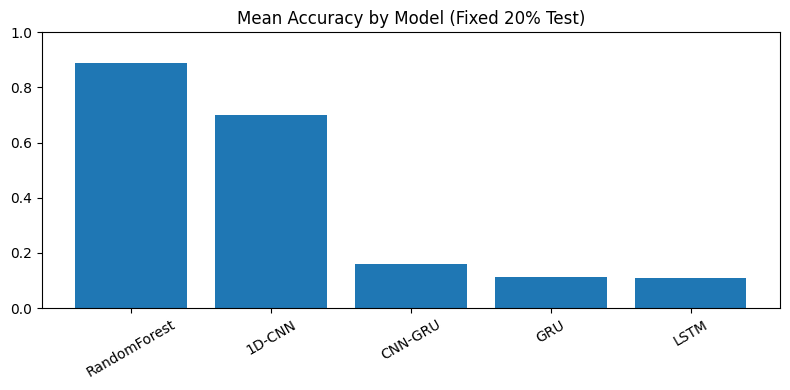

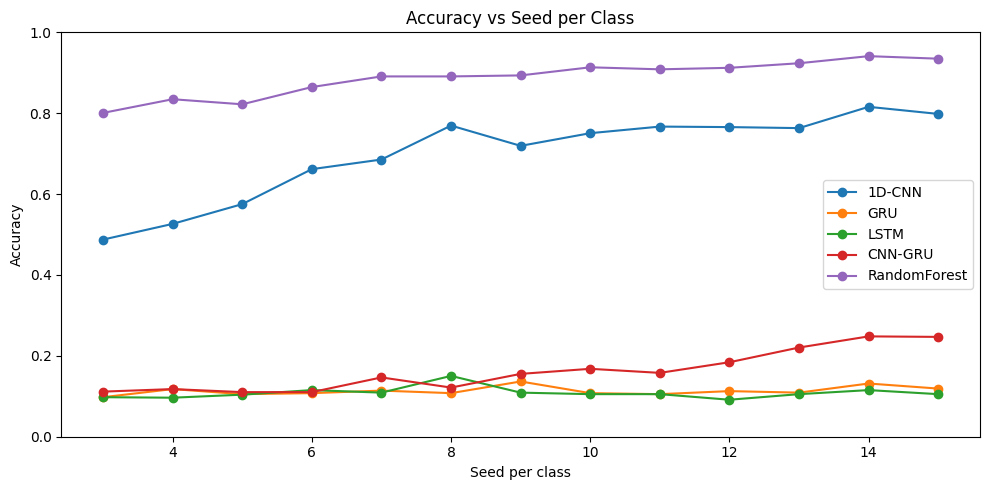

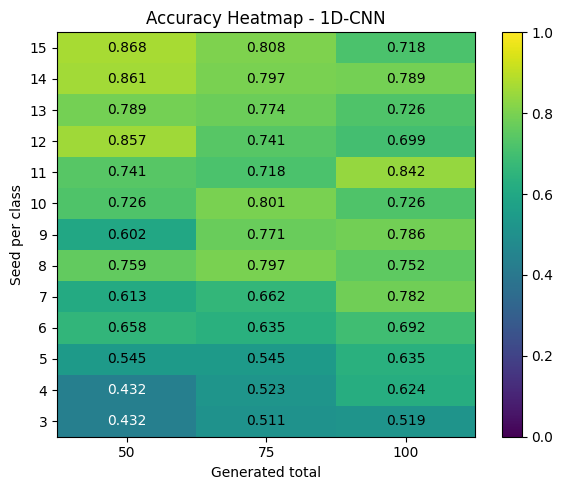

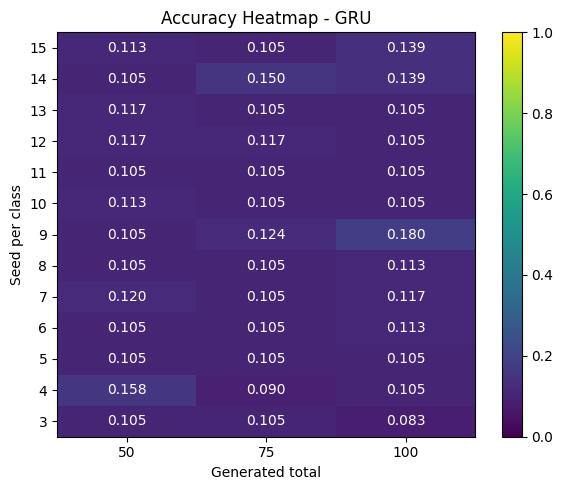

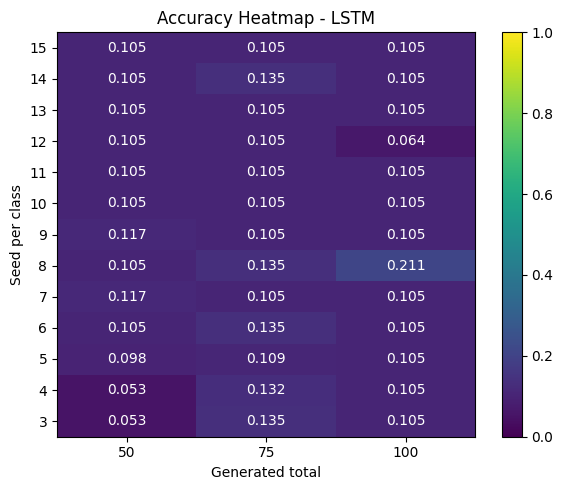

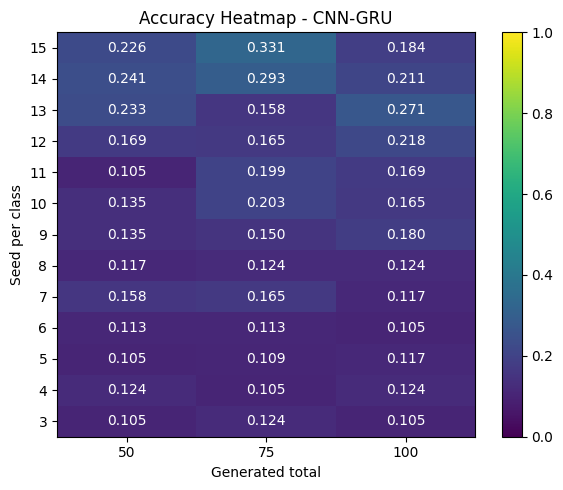

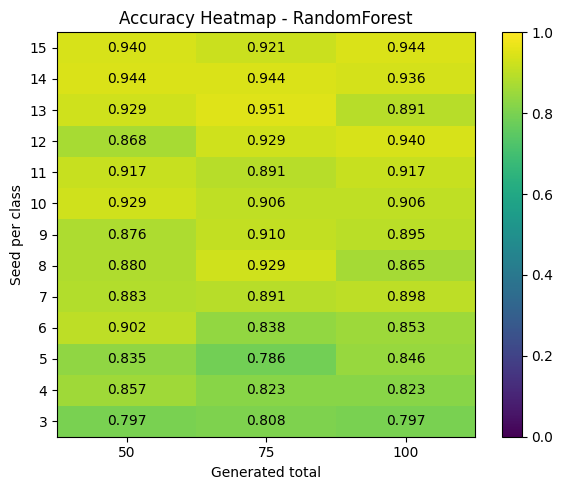

In [23]:
# Experiment: fixed 20% test, seed-per-class from 3..15, synthetic total in {50, 75, 100}
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Reuse model classes defined in the previous training cell:
# - CNN1DClassifier
# - GRUClassifier
# - LSTMClassifier
# - CNNGRUClassifier


def set_torch_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_seed_subset(X_pool, y_pool, seed_per_class, rng):
    seed_indices = []
    for cls in np.unique(y_pool):
        cls_idx = np.where(y_pool == cls)[0]
        if len(cls_idx) < seed_per_class:
            raise ValueError(f'Class {cls} has only {len(cls_idx)} samples, cannot take {seed_per_class} seeds.')
        chosen = rng.choice(cls_idx, size=seed_per_class, replace=False)
        seed_indices.extend(chosen.tolist())

    seed_indices = np.array(seed_indices)
    return X_pool[seed_indices], y_pool[seed_indices]


def generate_synthetic_from_seed(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)

    classes = np.unique(y_seed)
    n_classes = len(classes)

    # Allocate generated samples roughly uniformly across classes.
    per_cls = n_generate // n_classes
    remainder = n_generate % n_classes

    X_gen_list = []
    y_gen_list = []

    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue

        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6

        for _ in range(k):
            i1, i2 = rng.integers(0, len(cls_X), size=2)
            alpha = rng.uniform(0.2, 0.8)
            base = alpha * cls_X[i1] + (1.0 - alpha) * cls_X[i2]
            noise = rng.normal(loc=0.0, scale=noise_scale, size=base.shape) * cls_std.squeeze(0)
            synth = base + noise
            X_gen_list.append(synth.astype(np.float32))
            y_gen_list.append(cls)

    X_gen = np.stack(X_gen_list, axis=0) if X_gen_list else np.empty((0,) + X_seed.shape[1:], dtype=np.float32)
    y_gen = np.array(y_gen_list, dtype=y_seed.dtype)
    return X_gen, y_gen


def train_eval_model(model_name, X_train_local, y_train_local, X_test_local, y_test_local, seed):
    set_torch_seed(seed)

    # Scale with train-only min-max.
    scaler = MinMaxScaler()
    Xtr = scaler.fit_transform(X_train_local.reshape(-1, X_train_local.shape[-1])).reshape(X_train_local.shape)
    Xte = scaler.transform(X_test_local.reshape(-1, X_test_local.shape[-1])).reshape(X_test_local.shape)

    if model_name == 'RandomForest':
        Xtr_flat = Xtr.reshape(Xtr.shape[0], -1)
        Xte_flat = Xte.reshape(Xte.shape[0], -1)
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        rf.fit(Xtr_flat, y_train_local)
        y_pred = rf.predict(Xte_flat)
        return accuracy_score(y_test_local, y_pred)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train_local, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_features_local = Xtr.shape[2]
    num_classes_local = len(np.unique(y_train_local))

    if model_name == '1D-CNN':
        model = CNN1DClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'GRU':
        model = GRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'LSTM':
        model = LSTMClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'CNN-GRU':
        model = CNNGRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    else:
        raise ValueError(f'Unsupported model: {model_name}')

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()

    # Keep epochs moderate because we evaluate many settings and models.
    epochs = 8
    batch_size = 32

    model.train()
    n_train = len(y_train_local)
    indices = np.arange(n_train)
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, n_train, batch_size):
            idx = indices[start:start + batch_size]
            xb = Xtr_t[idx].to(device)
            yb = ytr_t[idx].to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(Xte_t.to(device))
        y_pred = logits.argmax(dim=1).cpu().numpy()

    return accuracy_score(y_test_local, y_pred)


# 1) Build fixed 20% test split once.
set_torch_seed(RANDOM_SEED)
le_exp = LabelEncoder()
y_exp = le_exp.fit_transform(y)

X_train_pool, X_test_fixed, y_train_pool, y_test_fixed = train_test_split(
    X,
    y_exp,
    test_size=0.20,
    stratify=y_exp,
    random_state=RANDOM_SEED,
)

# 2) Experiment grid.
SEED_COUNTS = list(range(3, 16))  # 3..15
GEN_COUNTS = [50, 75, 100]
MODELS = ['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']

rows = []
for seed_per_class in SEED_COUNTS:
    for gen_total in GEN_COUNTS:
        rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 100 + gen_total)

        X_seed, y_seed = make_seed_subset(X_train_pool, y_train_pool, seed_per_class, rng_local)
        X_gen, y_gen = generate_synthetic_from_seed(X_seed, y_seed, gen_total, rng_local, noise_scale=0.02)

        X_aug = np.concatenate([X_seed, X_gen], axis=0)
        y_aug = np.concatenate([y_seed, y_gen], axis=0)

        # Shuffle augmented train set.
        perm = rng_local.permutation(len(y_aug))
        X_aug = X_aug[perm]
        y_aug = y_aug[perm]

        for model_name in MODELS:
            acc = train_eval_model(model_name, X_aug, y_aug, X_test_fixed, y_test_fixed, RANDOM_SEED)
            rows.append({
                'seed_per_class': seed_per_class,
                'generated_total': gen_total,
                'train_size_augmented': len(y_aug),
                'model': model_name,
                'accuracy': acc,
            })
            print(f"seed={seed_per_class}, gen={gen_total}, model={model_name}, acc={acc:.4f}")

exp_df = pd.DataFrame(rows)
exp_out = output_dir / 'seed_synthetic_experiment_results.csv'
exp_df.to_csv(exp_out, index=False)

print('\nSaved experiment results to:', exp_out)
print('\nTop 10 settings by accuracy:')
print(exp_df.sort_values('accuracy', ascending=False).head(10))

print('\nMean accuracy by model:')
print(exp_df.groupby('model')['accuracy'].mean().sort_values(ascending=False))

pivot_mean = exp_df.pivot_table(
    index=['seed_per_class', 'generated_total'],
    columns='model',
    values='accuracy',
    aggfunc='mean',
).reset_index()

print('\nPivot (mean accuracy per setting):')
print(pivot_mean.head(15))

# 3) Visualization with matplotlib
# Plot A: mean accuracy by model
mean_by_model = exp_df.groupby('model', as_index=False)['accuracy'].mean().sort_values('accuracy', ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(mean_by_model['model'], mean_by_model['accuracy'])
plt.title('Mean Accuracy by Model (Fixed 20% Test)')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Plot B: accuracy vs seed_per_class per model
plt.figure(figsize=(10, 5))
for m in MODELS:
    curve = exp_df[exp_df['model'] == m].groupby('seed_per_class', as_index=False)['accuracy'].mean()
    plt.plot(curve['seed_per_class'], curve['accuracy'], marker='o', label=m)
plt.title('Accuracy vs Seed per Class')
plt.xlabel('Seed per class')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Plot C: heatmaps for each model using imshow
for m in MODELS:
    heat = exp_df[exp_df['model'] == m].pivot_table(
        index='seed_per_class',
        columns='generated_total',
        values='accuracy',
        aggfunc='mean',
    ).sort_index()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(heat.values, aspect='auto', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Accuracy Heatmap - {m}')
    ax.set_xlabel('Generated total')
    ax.set_ylabel('Seed per class')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f"{heat.values[i, j]:.3f}", ha='center', va='center', color='white' if heat.values[i, j] < 0.5 else 'black')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## Five Practical Generation Methods for Time-Series Augmentation

Để benchmark được ngay trong notebook, 5 phương pháp dưới đây được triển khai theo hướng augmentation/synthetic generation cho chuỗi thời gian:
- Mixup + Jitter
- Magnitude Scaling + Jitter
- Time Shift + Jitter
- Time Warping + Jitter
- Permutation + Jitter

Thí nghiệm giữ fixed 20% test, quét `seed_per_class` từ 3 đến 20, rồi so sánh accuracy theo từng model và từng phương pháp generate.

method=mixup_jitter, seed=3, model=1D-CNN, acc=0.4812
method=mixup_jitter, seed=3, model=GRU, acc=0.1053
method=mixup_jitter, seed=3, model=LSTM, acc=0.0526
method=mixup_jitter, seed=3, model=CNN-GRU, acc=0.0639
method=mixup_jitter, seed=3, model=RandomForest, acc=0.7218
method=mixup_jitter, seed=4, model=1D-CNN, acc=0.4135
method=mixup_jitter, seed=4, model=GRU, acc=0.1579
method=mixup_jitter, seed=4, model=LSTM, acc=0.1053
method=mixup_jitter, seed=4, model=CNN-GRU, acc=0.1165
method=mixup_jitter, seed=4, model=RandomForest, acc=0.8383
method=mixup_jitter, seed=5, model=1D-CNN, acc=0.4737
method=mixup_jitter, seed=5, model=GRU, acc=0.1053
method=mixup_jitter, seed=5, model=LSTM, acc=0.0752
method=mixup_jitter, seed=5, model=CNN-GRU, acc=0.1579
method=mixup_jitter, seed=5, model=RandomForest, acc=0.8684
method=mixup_jitter, seed=6, model=1D-CNN, acc=0.6128
method=mixup_jitter, seed=6, model=GRU, acc=0.1241
method=mixup_jitter, seed=6, model=LSTM, acc=0.1203
method=mixup_jitter, seed=6

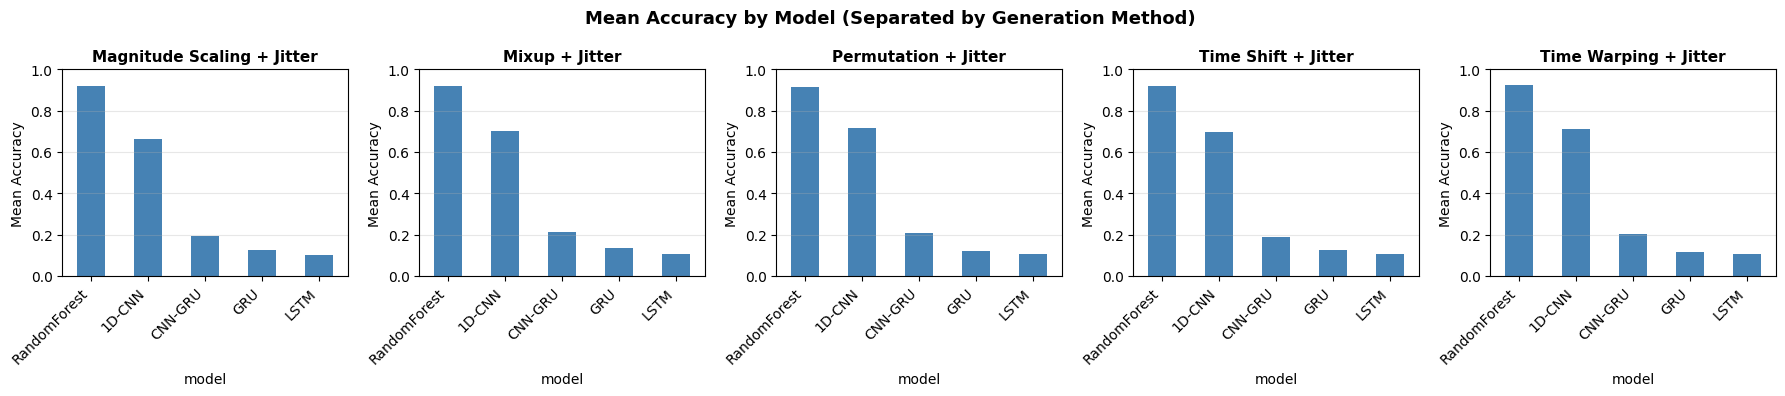

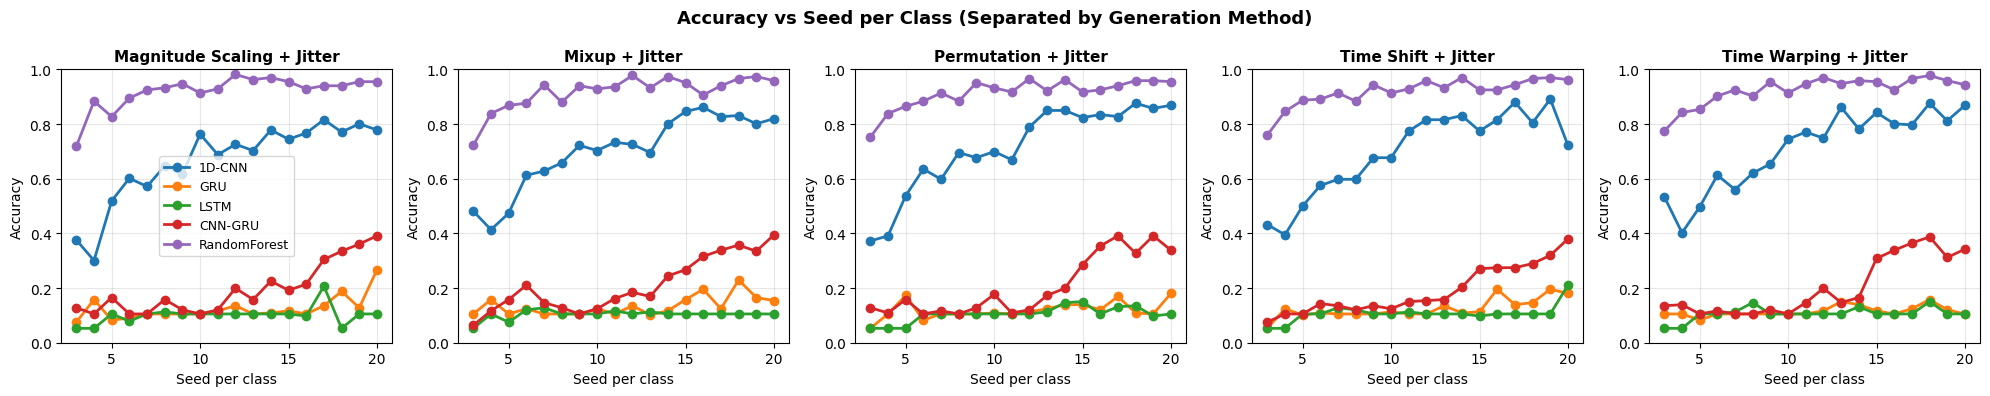

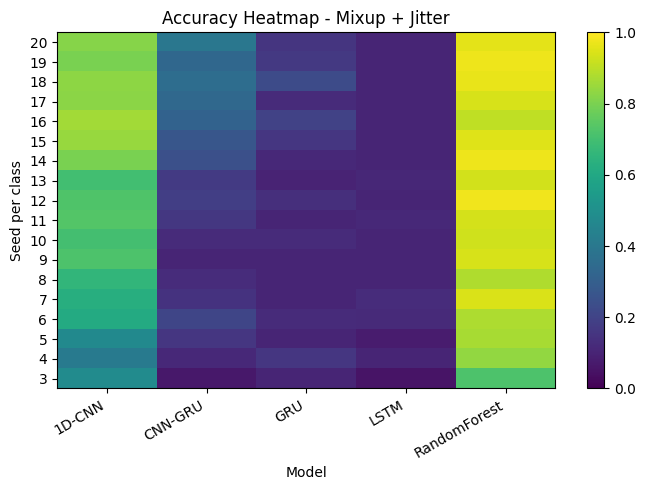

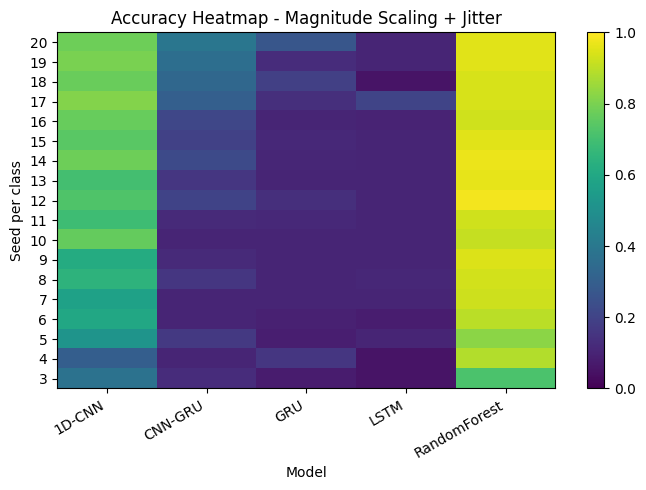

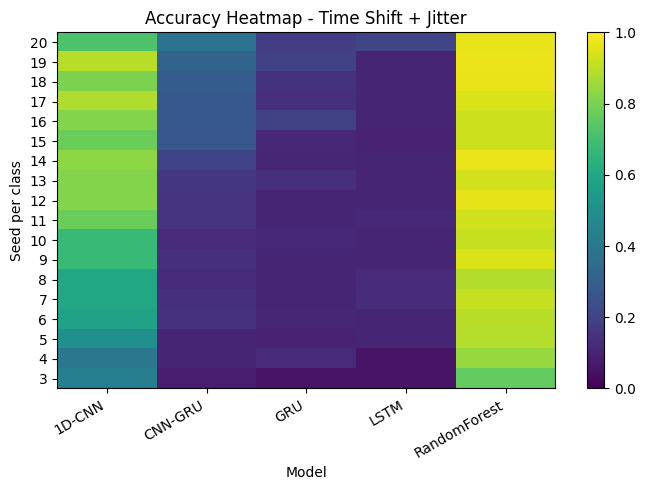

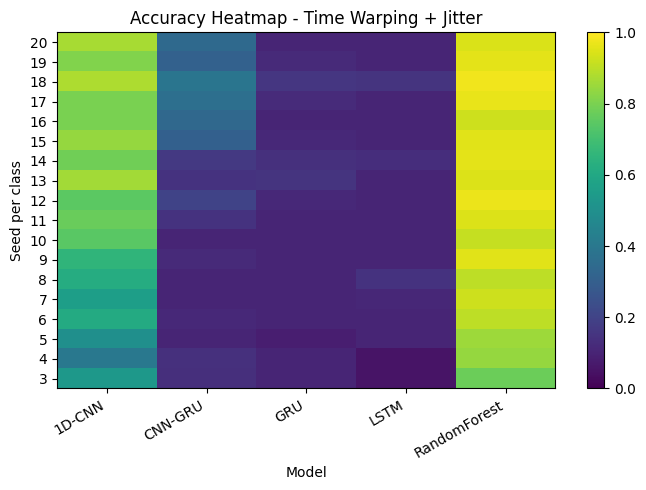

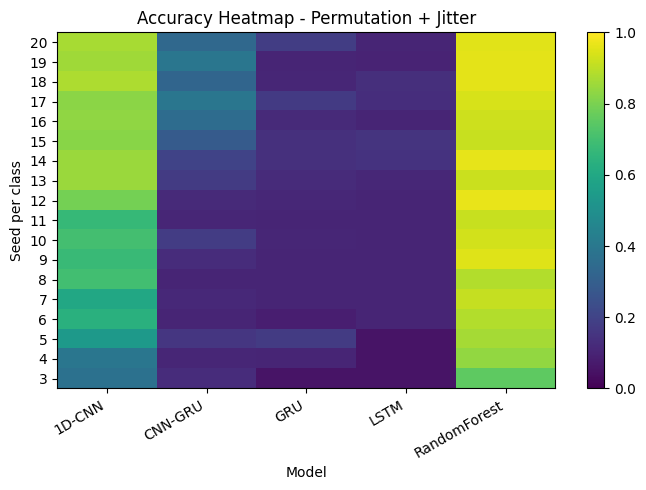

In [24]:
# Benchmark 5 generation methods on seed_per_class = 3..20 with fixed 20% test set
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


METHODS = [
    'mixup_jitter',
    'magnitude_scaling',
    'time_shift',
    'time_warp',
    'permutation',
]

METHOD_LABELS = {
    'mixup_jitter': 'Mixup + Jitter',
    'magnitude_scaling': 'Magnitude Scaling + Jitter',
    'time_shift': 'Time Shift + Jitter',
    'time_warp': 'Time Warping + Jitter',
    'permutation': 'Permutation + Jitter',
}

MODELS_5 = ['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']
SEED_COUNTS_5 = list(range(3, 21))  # 3..20


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def fixed_test_split(X_all, y_all, seed=RANDOM_SEED):
    return train_test_split(
        X_all,
        y_all,
        test_size=0.20,
        stratify=y_all,
        random_state=seed,
    )


def make_seed_subset(X_pool, y_pool, seed_per_class, rng):
    seed_indices = []
    for cls in np.unique(y_pool):
        cls_idx = np.where(y_pool == cls)[0]
        if len(cls_idx) < seed_per_class:
            raise ValueError(f'Class {cls} has only {len(cls_idx)} samples, cannot take {seed_per_class} seeds.')
        seed_indices.extend(rng.choice(cls_idx, size=seed_per_class, replace=False).tolist())
    seed_indices = np.array(seed_indices)
    return X_pool[seed_indices], y_pool[seed_indices]


def interpolate_along_time(x1, x2, rng, alpha_range=(0.2, 0.8)):
    alpha = rng.uniform(*alpha_range)
    return alpha * x1 + (1.0 - alpha) * x2


def apply_mixup_jitter(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    return _generate_by_interpolation(X_seed, y_seed, n_generate, rng, noise_scale=noise_scale)


def apply_magnitude_scaling(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []
    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6
        for _ in range(k):
            src = cls_X[rng.integers(0, len(cls_X))].copy()
            scale = rng.normal(loc=1.0, scale=0.10, size=(1, src.shape[1]))
            jitter = rng.normal(loc=0.0, scale=noise_scale, size=src.shape) * cls_std.squeeze(0)
            x_list.append((src * scale + jitter).astype(np.float32))
            y_list.append(cls)
    return np.stack(x_list, axis=0), np.array(y_list, dtype=y_seed.dtype)


def apply_time_shift(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []
    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6
        for _ in range(k):
            src = cls_X[rng.integers(0, len(cls_X))].copy()
            shift = int(rng.integers(-10, 11))
            shifted = np.roll(src, shift=shift, axis=0)
            jitter = rng.normal(loc=0.0, scale=noise_scale, size=shifted.shape) * cls_std.squeeze(0)
            x_list.append((shifted + jitter).astype(np.float32))
            y_list.append(cls)
    return np.stack(x_list, axis=0), np.array(y_list, dtype=y_seed.dtype)


def apply_time_warp(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []
    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6
        for _ in range(k):
            src = cls_X[rng.integers(0, len(cls_X))].copy()
            t = np.linspace(0, 1, src.shape[0])
            knot = np.sort(rng.uniform(0.1, 0.9, size=3))
            warp_pts = np.concatenate(([0.0], knot, [1.0]))
            warp_vals = np.concatenate(([0.0], np.cumsum(rng.uniform(0.7, 1.3, size=3)), [1.0]))
            warp_vals = warp_vals / warp_vals[-1]
            new_t = np.interp(t, warp_pts, warp_vals)
            warped = np.stack([
                np.interp(t, new_t, src[:, f]) for f in range(src.shape[1])
            ], axis=1)
            jitter = rng.normal(loc=0.0, scale=noise_scale, size=warped.shape) * cls_std.squeeze(0)
            x_list.append((warped + jitter).astype(np.float32))
            y_list.append(cls)
    return np.stack(x_list, axis=0), np.array(y_list, dtype=y_seed.dtype)


def apply_permutation(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []
    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6
        for _ in range(k):
            src = cls_X[rng.integers(0, len(cls_X))].copy()
            n_segments = int(rng.integers(3, 7))
            cuts = np.sort(rng.choice(np.arange(1, src.shape[0]), size=n_segments - 1, replace=False))
            segments = np.split(src, cuts, axis=0)
            rng.shuffle(segments)
            permuted = np.concatenate(segments, axis=0)
            jitter = rng.normal(loc=0.0, scale=noise_scale, size=permuted.shape) * cls_std.squeeze(0)
            x_list.append((permuted + jitter).astype(np.float32))
            y_list.append(cls)
    return np.stack(x_list, axis=0), np.array(y_list, dtype=y_seed.dtype)


def _generate_by_interpolation(X_seed, y_seed, n_generate, rng, noise_scale=0.02):
    if n_generate <= 0:
        return np.empty((0,) + X_seed.shape[1:], dtype=np.float32), np.empty((0,), dtype=y_seed.dtype)
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []
    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        cls_std = cls_X.std(axis=0, keepdims=True) + 1e-6
        for _ in range(k):
            i1, i2 = rng.integers(0, len(cls_X), size=2)
            base = interpolate_along_time(cls_X[i1], cls_X[i2], rng)
            jitter = rng.normal(loc=0.0, scale=noise_scale, size=base.shape) * cls_std.squeeze(0)
            x_list.append((base + jitter).astype(np.float32))
            y_list.append(cls)
    return np.stack(x_list, axis=0), np.array(y_list, dtype=y_seed.dtype)


GEN_METHODS = {
    'mixup_jitter': apply_mixup_jitter,
    'magnitude_scaling': apply_magnitude_scaling,
    'time_shift': apply_time_shift,
    'time_warp': apply_time_warp,
    'permutation': apply_permutation,
}


def train_eval_model(model_name, X_train_local, y_train_local, X_test_local, y_test_local, seed):
    set_all_seeds(seed)
    scaler = MinMaxScaler()
    Xtr = scaler.fit_transform(X_train_local.reshape(-1, X_train_local.shape[-1])).reshape(X_train_local.shape)
    Xte = scaler.transform(X_test_local.reshape(-1, X_test_local.shape[-1])).reshape(X_test_local.shape)

    if model_name == 'RandomForest':
        Xtr_flat = Xtr.reshape(Xtr.shape[0], -1)
        Xte_flat = Xte.reshape(Xte.shape[0], -1)
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        rf.fit(Xtr_flat, y_train_local)
        y_pred = rf.predict(Xte_flat)
        return accuracy_score(y_test_local, y_pred)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train_local, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_features_local = Xtr.shape[2]
    num_classes_local = len(np.unique(y_train_local))

    if model_name == '1D-CNN':
        model = CNN1DClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'GRU':
        model = GRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'LSTM':
        model = LSTMClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'CNN-GRU':
        model = CNNGRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    else:
        raise ValueError(f'Unsupported model: {model_name}')

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    epochs = 8
    batch_size = 32

    model.train()
    n_train = len(y_train_local)
    indices = np.arange(n_train)
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, n_train, batch_size):
            idx = indices[start:start + batch_size]
            xb = Xtr_t[idx].to(device)
            yb = ytr_t[idx].to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(Xte_t.to(device))
        y_pred = logits.argmax(dim=1).cpu().numpy()
    return accuracy_score(y_test_local, y_pred)


# Build fixed test split once.
set_all_seeds(RANDOM_SEED)
le_methods = LabelEncoder()
y_encoded = le_methods.fit_transform(y)
X_train_pool, X_test_fixed, y_train_pool, y_test_fixed = fixed_test_split(X, y_encoded, RANDOM_SEED)

rows = []
for method_name, generator_fn in GEN_METHODS.items():
    for seed_per_class in SEED_COUNTS_5:
        rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 100)
        X_seed, y_seed = make_seed_subset(X_train_pool, y_train_pool, seed_per_class, rng_local)
        # generate synthetic count proportional to seed count so we can compare across seeds
        n_generate = max(50, seed_per_class * 5)
        X_gen, y_gen = generator_fn(X_seed, y_seed, n_generate, rng_local)
        X_aug = np.concatenate([X_seed, X_gen], axis=0)
        y_aug = np.concatenate([y_seed, y_gen], axis=0)
        perm = rng_local.permutation(len(y_aug))
        X_aug = X_aug[perm]
        y_aug = y_aug[perm]

        for model_name in MODELS_5:
            acc = train_eval_model(model_name, X_aug, y_aug, X_test_fixed, y_test_fixed, RANDOM_SEED)
            rows.append({
                'method': method_name,
                'method_label': METHOD_LABELS[method_name],
                'seed_per_class': seed_per_class,
                'generated_total': len(y_gen),
                'train_size_augmented': len(y_aug),
                'model': model_name,
                'accuracy': acc,
            })
            print(f"method={method_name}, seed={seed_per_class}, model={model_name}, acc={acc:.4f}")

methods_df = pd.DataFrame(rows)
methods_out = output_dir / 'five_method_seed_3_20_results.csv'
methods_df.to_csv(methods_out, index=False)
print('\nSaved 5-method results to:', methods_out)
print('\nMean accuracy by method and model:')
print(methods_df.groupby(['method_label', 'model'])['accuracy'].mean().sort_values(ascending=False))

# Plot 1: mean accuracy by method/model (separated by method)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, method_label in enumerate(sorted(methods_df['method_label'].unique())):
    ax = axes[idx]
    data = methods_df[methods_df['method_label'] == method_label].groupby('model')['accuracy'].mean().sort_values(ascending=False)
    data.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{method_label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Accuracy')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(data.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
fig.suptitle('Mean Accuracy by Model (Separated by Generation Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: accuracy vs seed per class (separated by method)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, method_label in enumerate(sorted(methods_df['method_label'].unique())):
    ax = axes[idx]
    method_data = methods_df[methods_df['method_label'] == method_label]
    for model_name in MODELS_5:
        curve = method_data[method_data['model'] == model_name].groupby('seed_per_class', as_index=False)['accuracy'].mean()
        if len(curve) > 0:
            ax.plot(curve['seed_per_class'], curve['accuracy'], marker='o', label=model_name, linewidth=2)
    ax.set_title(f'{method_label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9, loc='best')
fig.suptitle('Accuracy vs Seed per Class (Separated by Generation Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: heatmaps per method
for method_label in methods_df['method_label'].unique():
    fig, ax = plt.subplots(figsize=(7, 5))
    heat = methods_df[methods_df['method_label'] == method_label].pivot_table(
        index='seed_per_class',
        columns='model',
        values='accuracy',
        aggfunc='mean',
    ).sort_index()
    im = ax.imshow(heat.values, aspect='auto', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Accuracy Heatmap - {method_label}')
    ax.set_xlabel('Model')
    ax.set_ylabel('Seed per class')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


## TimeGAN-based Synthetic Data Generation

Thêm phương pháp thứ 6 sử dụng TimeGAN (Temporal Generative Adversarial Network) để sinh dữ liệu synthetic từ seed data.

TimeGAN gồm 3 thành phần:
- **Embedder**: Encode time series thành latent space
- **Recovery**: Decode latent trở lại time series  
- **Discriminator**: Phân biệt real vs synthetic data

Huấn luyện trên seed data, rồi generate synthetic samples.


Running TimeGAN-only experiment on device: cpu
seed=3, model=1D-CNN, acc=0.1654
seed=3, model=GRU, acc=0.0526
seed=3, model=LSTM, acc=0.0526
seed=3, model=CNN-GRU, acc=0.0526
seed=3, model=RandomForest, acc=0.8346
seed=4, model=1D-CNN, acc=0.1504
seed=4, model=GRU, acc=0.0526
seed=4, model=LSTM, acc=0.0526
seed=4, model=CNN-GRU, acc=0.0526
seed=4, model=RandomForest, acc=0.8722
seed=5, model=1D-CNN, acc=0.1842
seed=5, model=GRU, acc=0.0526
seed=5, model=LSTM, acc=0.0526
seed=5, model=CNN-GRU, acc=0.0865
seed=5, model=RandomForest, acc=0.8947
seed=6, model=1D-CNN, acc=0.0865
seed=6, model=GRU, acc=0.0526
seed=6, model=LSTM, acc=0.0526
seed=6, model=CNN-GRU, acc=0.0677
seed=6, model=RandomForest, acc=0.8947
seed=7, model=1D-CNN, acc=0.0827
seed=7, model=GRU, acc=0.0526
seed=7, model=LSTM, acc=0.0526
seed=7, model=CNN-GRU, acc=0.0526
seed=7, model=RandomForest, acc=0.9511
seed=8, model=1D-CNN, acc=0.1504
seed=8, model=GRU, acc=0.0526
seed=8, model=LSTM, acc=0.0526
seed=8, model=CNN-GRU, a

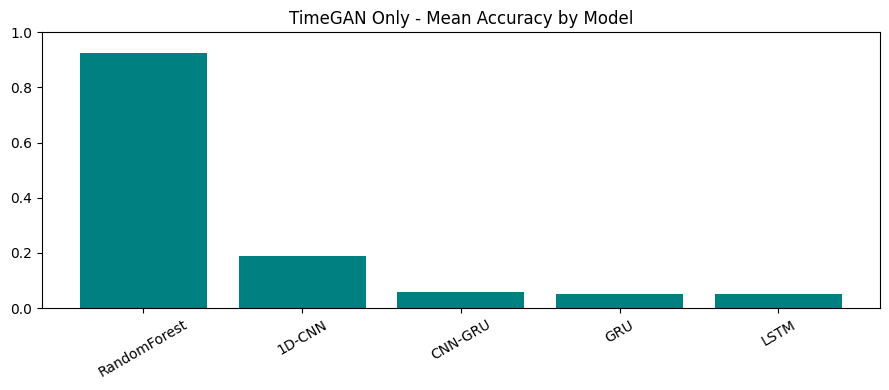

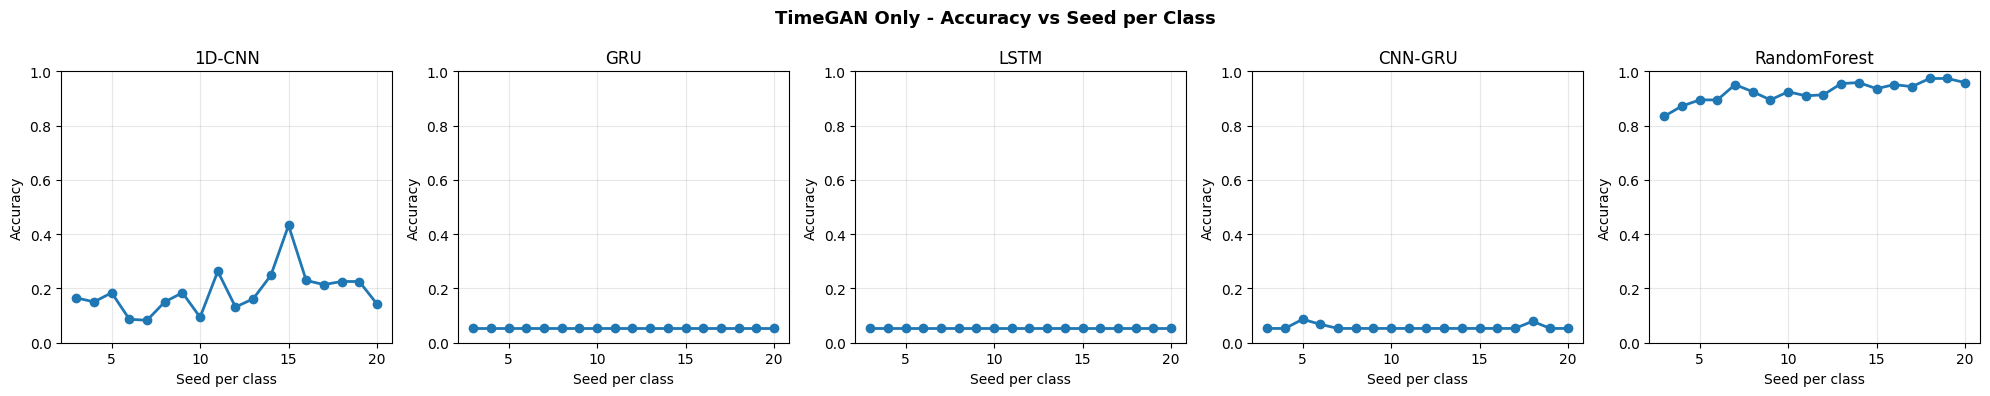

In [25]:
# TimeGAN-only experiment: train/generate/evaluate without rerunning the 5-method benchmark
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


class TimeGANGenerator(nn.Module):
    def __init__(self, num_features, latent_dim=32, hidden_dim=64):
        super().__init__()
        self.encoder = nn.GRU(num_features, hidden_dim, batch_first=True)
        self.project = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.GRU(latent_dim, hidden_dim, batch_first=True)
        self.reconstruct = nn.Linear(hidden_dim, num_features)

    def forward(self, x):
        _, h = self.encoder(x)
        z = self.project(h.squeeze(0))
        z_seq = z.unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(z_seq)
        return self.reconstruct(out)

    def generate(self, n_samples, seq_len, device):
        self.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, seq_len, self.project.out_features, device=device)
            out, _ = self.decoder(z)
            return self.reconstruct(out).cpu().numpy().astype(np.float32)


def train_timegan_on_seed(X_seed, device, epochs=30, batch_size=16, lr=1e-3):
    model = TimeGANGenerator(num_features=X_seed.shape[2], latent_dim=32, hidden_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    X_t = torch.tensor(X_seed, dtype=torch.float32, device=device)

    model.train()
    indices = np.arange(len(X_seed))
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            xb = X_t[batch_idx]
            optimizer.zero_grad()
            x_hat = model(xb)
            loss = criterion(x_hat, xb)
            loss.backward()
            optimizer.step()
    return model


def timegan_generate_by_class(X_seed, y_seed, n_generate, device, epochs=30):
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []

    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        cls_X = X_seed[y_seed == cls]
        model = train_timegan_on_seed(cls_X, device=device, epochs=epochs)
        x_gen = model.generate(k, seq_len=cls_X.shape[1], device=device)
        x_list.append(x_gen)
        y_list.append(np.full(k, cls, dtype=y_seed.dtype))

    X_gen = np.concatenate(x_list, axis=0) if x_list else np.empty((0,) + X_seed.shape[1:], dtype=np.float32)
    y_gen = np.concatenate(y_list, axis=0) if y_list else np.empty((0,), dtype=y_seed.dtype)
    return X_gen, y_gen


def timegan_only_train_eval(model_name, X_train_local, y_train_local, X_test_local, y_test_local, seed):
    # Reuse the same evaluation logic as the earlier benchmark cell.
    set_all_seeds(seed)
    scaler = MinMaxScaler()
    Xtr = scaler.fit_transform(X_train_local.reshape(-1, X_train_local.shape[-1])).reshape(X_train_local.shape)
    Xte = scaler.transform(X_test_local.reshape(-1, X_test_local.shape[-1])).reshape(X_test_local.shape)

    if model_name == 'RandomForest':
        Xtr_flat = Xtr.reshape(Xtr.shape[0], -1)
        Xte_flat = Xte.reshape(Xte.shape[0], -1)
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        rf.fit(Xtr_flat, y_train_local)
        y_pred = rf.predict(Xte_flat)
        return accuracy_score(y_test_local, y_pred)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train_local, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_features_local = Xtr.shape[2]
    num_classes_local = len(np.unique(y_train_local))

    if model_name == '1D-CNN':
        model = CNN1DClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'GRU':
        model = GRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'LSTM':
        model = LSTMClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'CNN-GRU':
        model = CNNGRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    else:
        raise ValueError(f'Unsupported model: {model_name}')

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    epochs = 8
    batch_size = 32

    model.train()
    n_train = len(y_train_local)
    indices = np.arange(n_train)
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, n_train, batch_size):
            idx = indices[start:start + batch_size]
            xb = Xtr_t[idx].to(device)
            yb = ytr_t[idx].to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(Xte_t.to(device))
        y_pred = logits.argmax(dim=1).cpu().numpy()
    return accuracy_score(y_test_local, y_pred)


# Fixed split, using the same setup as the main notebook.
set_all_seeds(RANDOM_SEED)
le_timegan = LabelEncoder()
y_timegan = le_timegan.fit_transform(y)
X_train_pool_tg, X_test_fixed_tg, y_train_pool_tg, y_test_fixed_tg = train_test_split(
    X,
    y_timegan,
    test_size=0.20,
    stratify=y_timegan,
    random_state=RANDOM_SEED,
)

TIMEGAN_SEEDS = list(range(3, 21))
TIMEGAN_MODELS = ['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']
TIMEGAN_RESULTS = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Running TimeGAN-only experiment on device: {device}')
for seed_per_class in TIMEGAN_SEEDS:
    rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 1000)
    X_seed, y_seed = make_seed_subset(X_train_pool_tg, y_train_pool_tg, seed_per_class, rng_local)
    n_generate = max(50, seed_per_class * 5)
    X_gen, y_gen = timegan_generate_by_class(X_seed, y_seed, n_generate, device=device, epochs=20)

    X_aug = np.concatenate([X_seed, X_gen], axis=0)
    y_aug = np.concatenate([y_seed, y_gen], axis=0)
    perm = rng_local.permutation(len(y_aug))
    X_aug = X_aug[perm]
    y_aug = y_aug[perm]

    for model_name in TIMEGAN_MODELS:
        acc = timegan_only_train_eval(model_name, X_aug, y_aug, X_test_fixed_tg, y_test_fixed_tg, RANDOM_SEED)
        TIMEGAN_RESULTS.append({
            'method': 'timegan',
            'method_label': 'TimeGAN',
            'seed_per_class': seed_per_class,
            'generated_total': len(y_gen),
            'train_size_augmented': len(y_aug),
            'model': model_name,
            'accuracy': acc,
        })
        print(f'seed={seed_per_class}, model={model_name}, acc={acc:.4f}')

TIMEGAN_DF = pd.DataFrame(TIMEGAN_RESULTS)
TIMEGAN_OUT = output_dir / 'timegan_only_results.csv'
TIMEGAN_DF.to_csv(TIMEGAN_OUT, index=False)
print('\nSaved TimeGAN-only results to:', TIMEGAN_OUT)
print('\nMean accuracy by model:')
print(TIMEGAN_DF.groupby('model')['accuracy'].mean().sort_values(ascending=False))

# Visualization: one figure per model, and one summary line chart.
plt.figure(figsize=(9, 4))
mean_by_model = TIMEGAN_DF.groupby('model', as_index=False)['accuracy'].mean().sort_values('accuracy', ascending=False)
plt.bar(mean_by_model['model'], mean_by_model['accuracy'], color='teal')
plt.title('TimeGAN Only - Mean Accuracy by Model')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(TIMEGAN_MODELS), figsize=(20, 4))
for idx, model_name in enumerate(TIMEGAN_MODELS):
    ax = axes[idx]
    curve = TIMEGAN_DF[TIMEGAN_DF['model'] == model_name].groupby('seed_per_class', as_index=False)['accuracy'].mean()
    ax.plot(curve['seed_per_class'], curve['accuracy'], marker='o', linewidth=2)
    ax.set_title(model_name)
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
fig.suptitle('TimeGAN Only - Accuracy vs Seed per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Running Conditional TimeGAN experiment on device: cpu
seed=3, model=1D-CNN, acc=0.0827
seed=3, model=GRU, acc=0.0526
seed=3, model=LSTM, acc=0.0526
seed=3, model=CNN-GRU, acc=0.0526
seed=3, model=RandomForest, acc=0.7857
seed=5, model=1D-CNN, acc=0.1241
seed=5, model=GRU, acc=0.0526
seed=5, model=LSTM, acc=0.0526
seed=5, model=CNN-GRU, acc=0.0526
seed=5, model=RandomForest, acc=0.8947
seed=8, model=1D-CNN, acc=0.1767
seed=8, model=GRU, acc=0.0526
seed=8, model=LSTM, acc=0.0526
seed=8, model=CNN-GRU, acc=0.0677
seed=8, model=RandomForest, acc=0.9060
seed=10, model=1D-CNN, acc=0.2481
seed=10, model=GRU, acc=0.0526
seed=10, model=LSTM, acc=0.0526
seed=10, model=CNN-GRU, acc=0.0526
seed=10, model=RandomForest, acc=0.9173
seed=12, model=1D-CNN, acc=0.1880
seed=12, model=GRU, acc=0.0526
seed=12, model=LSTM, acc=0.0526
seed=12, model=CNN-GRU, acc=0.0526
seed=12, model=RandomForest, acc=0.9173
seed=15, model=1D-CNN, acc=0.1654
seed=15, model=GRU, acc=0.0526
seed=15, model=LSTM, acc=0.0526
seed

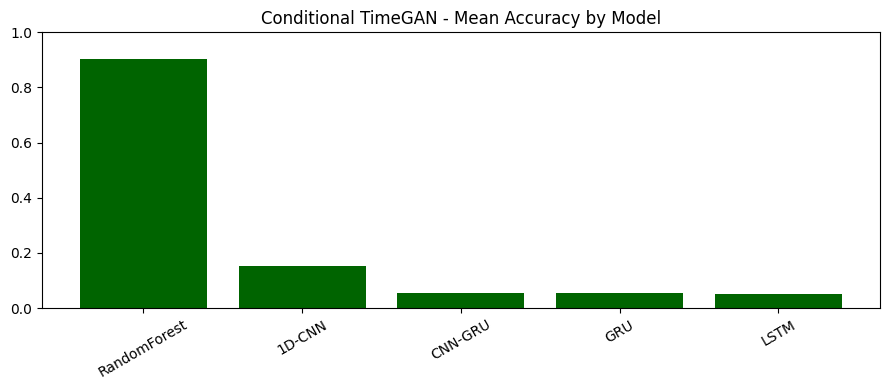

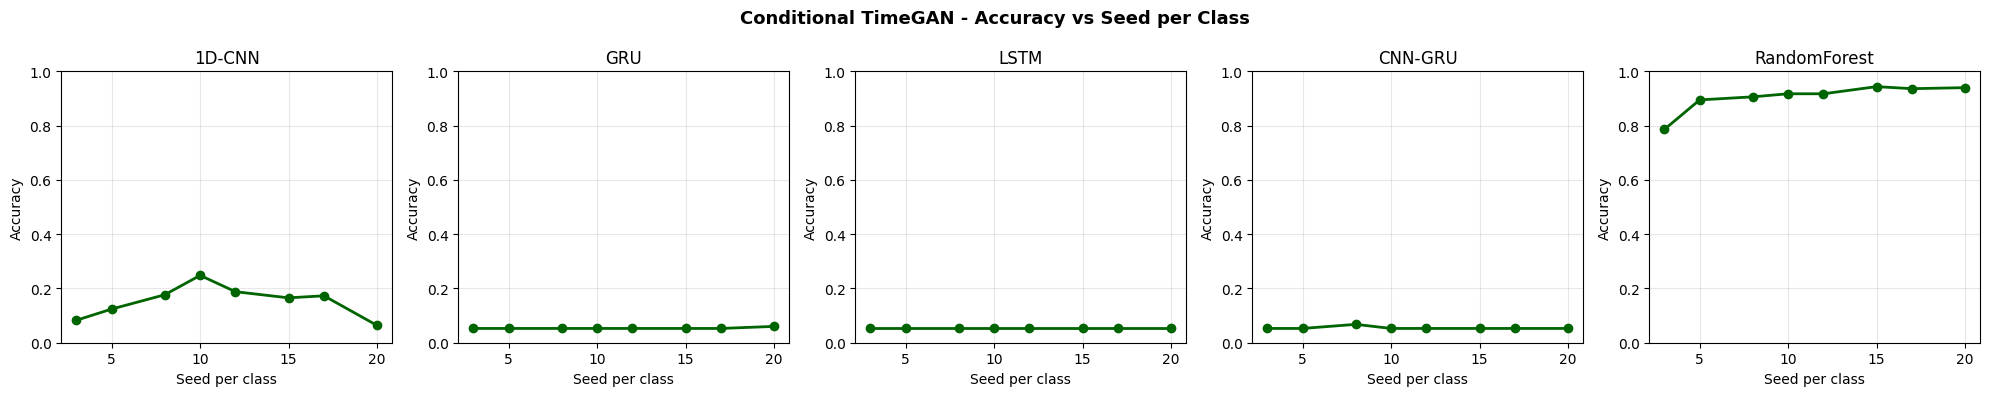

In [49]:

# Conditional TimeGAN experiment: add class embedding for improved generation
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


class ConditionalTimeGANGenerator(nn.Module):
    """TimeGAN with class conditioning via embedding"""
    def __init__(self, num_features, num_classes, latent_dim=32, hidden_dim=64, embed_dim=8):
        super().__init__()
        self.embed_dim = embed_dim
        self.class_embedding = nn.Embedding(num_classes, embed_dim)
        self.encoder = nn.GRU(num_features + embed_dim, hidden_dim, batch_first=True)
        self.project = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.GRU(latent_dim + embed_dim, hidden_dim, batch_first=True)
        self.reconstruct = nn.Linear(hidden_dim, num_features)

    def forward(self, x, c):
        """
        Args:
            x: (B, T, F) - input sequences
            c: (B,) - class labels
        """
        c_emb = self.class_embedding(c)  # (B, embed_dim)
        c_seq = c_emb.unsqueeze(1).expand(-1, x.size(1), -1)  # (B, T, embed_dim)
        x_c = torch.cat([x, c_seq], dim=-1)  # (B, T, F + embed_dim)
        
        _, h = self.encoder(x_c)
        z = self.project(h.squeeze(0))  # (B, latent_dim)
        z_seq = z.unsqueeze(1).repeat(1, x.size(1), 1)  # (B, T, latent_dim)
        z_c = torch.cat([z_seq, c_seq], dim=-1)  # (B, T, latent_dim + embed_dim)
        
        out, _ = self.decoder(z_c)
        return self.reconstruct(out)

    def generate(self, n_samples, seq_len, class_id, device):
        """Generate samples for a specific class"""
        self.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, seq_len, self.project.out_features, device=device)
            c = torch.full((n_samples,), class_id, dtype=torch.long, device=device)
            c_emb = self.class_embedding(c)
            c_seq = c_emb.unsqueeze(1).repeat(1, seq_len, 1)
            z_c = torch.cat([z, c_seq], dim=-1)
            out, _ = self.decoder(z_c)
            return self.reconstruct(out).cpu().numpy().astype(np.float32)


def train_conditional_timegan(X_seed, y_seed, num_classes, device, epochs=30, batch_size=16, lr=1e-3):
    """Train conditional TimeGAN on seed data"""
    model = ConditionalTimeGANGenerator(
        num_features=X_seed.shape[2],
        num_classes=num_classes,
        latent_dim=32,
        hidden_dim=64,
        embed_dim=8
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    X_t = torch.tensor(X_seed, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_seed, dtype=torch.long, device=device)

    model.train()
    indices = np.arange(len(X_seed))
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            xb = X_t[batch_idx]
            yb = y_t[batch_idx]
            optimizer.zero_grad()
            x_hat = model(xb, yb)
            loss = criterion(x_hat, xb)
            loss.backward()
            optimizer.step()
    return model


def conditional_timegan_generate_by_class(X_seed, y_seed, n_generate, num_classes, device, epochs=30):
    """Generate samples for each class using conditional TimeGAN"""
    model = train_conditional_timegan(X_seed, y_seed, num_classes, device, epochs=epochs)
    
    classes = np.unique(y_seed)
    per_cls = n_generate // len(classes)
    remainder = n_generate % len(classes)
    x_list, y_list = [], []

    for i, cls in enumerate(classes):
        k = per_cls + (1 if i < remainder else 0)
        if k == 0:
            continue
        x_gen = model.generate(k, seq_len=X_seed.shape[1], class_id=int(cls), device=device)
        x_list.append(x_gen)
        y_list.append(np.full(k, cls, dtype=y_seed.dtype))

    X_gen = np.concatenate(x_list, axis=0) if x_list else np.empty((0,) + X_seed.shape[1:], dtype=np.float32)
    y_gen = np.concatenate(y_list, axis=0) if y_list else np.empty((0,), dtype=y_seed.dtype)
    return X_gen, y_gen


def conditional_timegan_train_eval(model_name, X_train_local, y_train_local, X_test_local, y_test_local, seed):
    """Evaluate a model trained on conditional TimeGAN augmented data"""
    set_all_seeds(seed)
    scaler = MinMaxScaler()
    Xtr = scaler.fit_transform(X_train_local.reshape(-1, X_train_local.shape[-1])).reshape(X_train_local.shape)
    Xte = scaler.transform(X_test_local.reshape(-1, X_test_local.shape[-1])).reshape(X_test_local.shape)

    if model_name == 'RandomForest':
        Xtr_flat = Xtr.reshape(Xtr.shape[0], -1)
        Xte_flat = Xte.reshape(Xte.shape[0], -1)
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        rf.fit(Xtr_flat, y_train_local)
        y_pred = rf.predict(Xte_flat)
        return accuracy_score(y_test_local, y_pred)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train_local, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_features_local = Xtr.shape[2]
    num_classes_local = len(np.unique(y_train_local))

    if model_name == '1D-CNN':
        model = CNN1DClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'GRU':
        model = GRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'LSTM':
        model = LSTMClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    elif model_name == 'CNN-GRU':
        model = CNNGRUClassifier(num_features=num_features_local, num_classes=num_classes_local).to(device)
    else:
        raise ValueError(f'Unsupported model: {model_name}')

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    epochs = 8
    batch_size = 32

    model.train()
    n_train = len(y_train_local)
    indices = np.arange(n_train)
    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, n_train, batch_size):
            idx = indices[start:start + batch_size]
            xb = Xtr_t[idx].to(device)
            yb = ytr_t[idx].to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(Xte_t.to(device))
        y_pred = logits.argmax(dim=1).cpu().numpy()
    return accuracy_score(y_test_local, y_pred)


# Run conditional TimeGAN benchmark
set_all_seeds(RANDOM_SEED)
le_cond_timegan = LabelEncoder()
y_cond_timegan = le_cond_timegan.fit_transform(y)
X_train_pool_ctg, X_test_fixed_ctg, y_train_pool_ctg, y_test_fixed_ctg = train_test_split(
    X,
    y_cond_timegan,
    test_size=0.20,
    stratify=y_cond_timegan,
    random_state=RANDOM_SEED,
)

COND_TIMEGAN_SEEDS = [3, 5, 8, 10, 12, 15, 17, 20]
COND_TIMEGAN_MODELS = ['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']
COND_TIMEGAN_RESULTS = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes_ctg = len(np.unique(y_cond_timegan))

print(f'Running Conditional TimeGAN experiment on device: {device}')
for seed_per_class in COND_TIMEGAN_SEEDS:
    rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 2000)
    X_seed, y_seed = make_seed_subset(X_train_pool_ctg, y_train_pool_ctg, seed_per_class, rng_local)
    n_generate = max(50, seed_per_class * 5)
    X_gen, y_gen = conditional_timegan_generate_by_class(X_seed, y_seed, n_generate, num_classes_ctg, device=device, epochs=20)

    X_aug = np.concatenate([X_seed, X_gen], axis=0)
    y_aug = np.concatenate([y_seed, y_gen], axis=0)
    perm = rng_local.permutation(len(y_aug))
    X_aug = X_aug[perm]
    y_aug = y_aug[perm]

    for model_name in COND_TIMEGAN_MODELS:
        acc = conditional_timegan_train_eval(model_name, X_aug, y_aug, X_test_fixed_ctg, y_test_fixed_ctg, RANDOM_SEED)
        COND_TIMEGAN_RESULTS.append({
            'method': 'conditional_timegan',
            'method_label': 'Conditional TimeGAN',
            'seed_per_class': seed_per_class,
            'generated_total': len(y_gen),
            'train_size_augmented': len(y_aug),
            'model': model_name,
            'accuracy': acc,
        })
        print(f'seed={seed_per_class}, model={model_name}, acc={acc:.4f}')

COND_TIMEGAN_DF = pd.DataFrame(COND_TIMEGAN_RESULTS)
COND_TIMEGAN_OUT = output_dir / 'conditional_timegan_results.csv'
COND_TIMEGAN_DF.to_csv(COND_TIMEGAN_OUT, index=False)
print('\nSaved Conditional TimeGAN results to:', COND_TIMEGAN_OUT)
print('\nMean accuracy by model:')
print(COND_TIMEGAN_DF.groupby('model')['accuracy'].mean().sort_values(ascending=False))

# Visualization: bar chart and line plots
plt.figure(figsize=(9, 4))
mean_by_model = COND_TIMEGAN_DF.groupby('model', as_index=False)['accuracy'].mean().sort_values('accuracy', ascending=False)
plt.bar(mean_by_model['model'], mean_by_model['accuracy'], color='darkgreen')
plt.title('Conditional TimeGAN - Mean Accuracy by Model')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(COND_TIMEGAN_MODELS), figsize=(20, 4))
for idx, model_name in enumerate(COND_TIMEGAN_MODELS):
    ax = axes[idx]
    curve = COND_TIMEGAN_DF[COND_TIMEGAN_DF['model'] == model_name].groupby('seed_per_class', as_index=False)['accuracy'].mean()
    ax.plot(curve['seed_per_class'], curve['accuracy'], marker='o', linewidth=2, color='darkgreen')
    ax.set_title(model_name)
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
fig.suptitle('Conditional TimeGAN - Accuracy vs Seed per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## So Sánh Chi Tiết: Hiệu Ứng của Các Phương Pháp Sinh Dữ Liệu Khác Nhau

So sánh **Seed-only vs từng phương pháp sinh riêng biệt** để thấy:
- Phương pháp sinh nào tốt nhất cho từng model?
- Hiệu ứng của augmentation là bao nhiêu?
- Các phương pháp khác nhau có hiệu ứng khác biệt nhiều không?

SO SÁNH CHI TIẾT: SEED-ONLY vs TỪNG PHƯƠNG PHÁP SINH

--- Seed = 3 ---
Seed data size: 57
  magnitude_scaling    | Synthetic:  50 | Total train: 107
  mixup_jitter         | Synthetic:  50 | Total train: 107
  permutation          | Synthetic:  50 | Total train: 107
  time_shift           | Synthetic:  50 | Total train: 107
  time_warp            | Synthetic:  50 | Total train: 107

--- Seed = 5 ---
Seed data size: 95
  magnitude_scaling    | Synthetic:  50 | Total train: 145
  mixup_jitter         | Synthetic:  50 | Total train: 145
  permutation          | Synthetic:  50 | Total train: 145
  time_shift           | Synthetic:  50 | Total train: 145
  time_warp            | Synthetic:  50 | Total train: 145

--- Seed = 10 ---
Seed data size: 190
  magnitude_scaling    | Synthetic:  50 | Total train: 240
  mixup_jitter         | Synthetic:  50 | Total train: 240
  permutation          | Synthetic:  50 | Total train: 240
  time_shift           | Synthetic:  50 | Total train: 240
  time_w

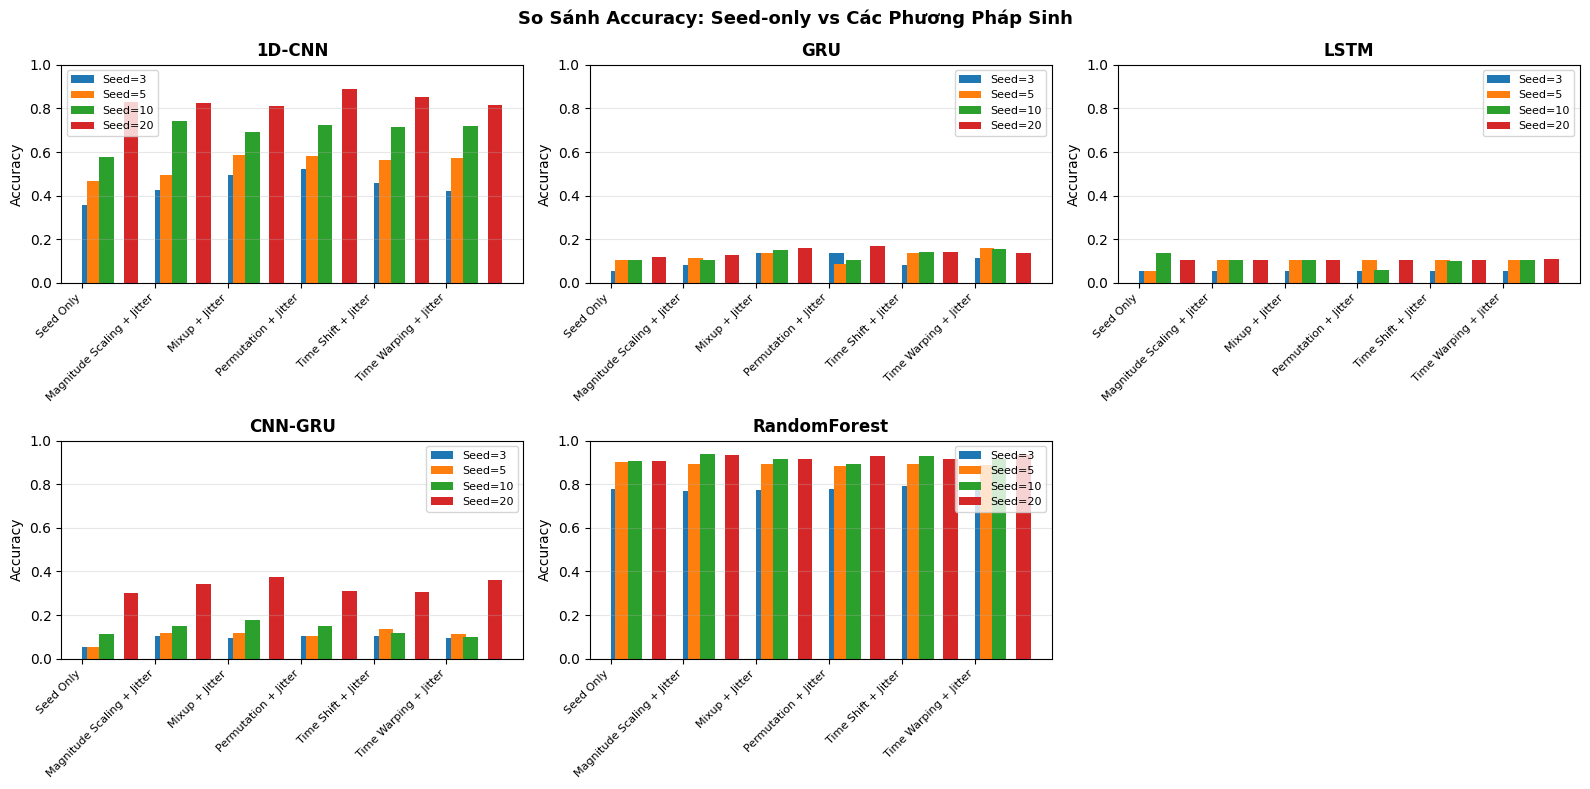

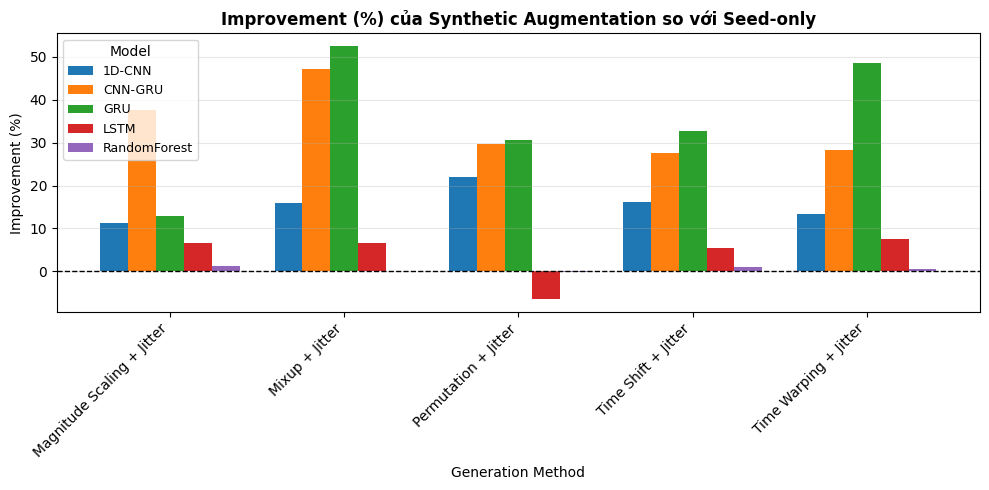


✅ Comparison finished. Elapsed: 145.4s


In [ ]:
# So sánh chi tiết: Seed-only vs từng phương pháp sinh cụ thể

import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*90)
print("SO SÁNH CHI TIẾT: SEED-ONLY vs TỪNG PHƯƠNG PHÁP SINH")
print("="*90)

start_time = time.time()

# Chuẩn bị dữ liệu
SEED_COUNTS_DETAIL = list(range(3, 21))  # Các seed from 3-20
METHODS_TO_COMPARE = sorted(GEN_METHODS.keys())  # Tất cả 5 phương pháp sinh
MODELS_TO_TEST = MODELS_5  # Tất cả 5 model

comparison_rows = []

for seed_per_class in SEED_COUNTS_DETAIL:
    rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 2000)
    
    # Bước 1: Tạo seed data (mẫu thật từ training pool)
    X_seed, y_seed = make_seed_subset(X_train_pool, y_train_pool, seed_per_class, rng_local)
    seed_size = len(y_seed)
    
    # Bước 2a: Train trên seed-only (không synthetic)
    print(f"\n--- Seed = {seed_per_class} ---")
    print(f"Seed data size: {seed_size}")
    
    for model_name in MODELS_TO_TEST:
        acc_seed = train_eval_model(
            model_name, X_seed, y_seed, X_test_fixed, y_test_fixed, RANDOM_SEED
        )
        comparison_rows.append({
            'seed_per_class': seed_per_class,
            'method': 'seed_only',
            'method_label': 'Seed Only (No Synthetic)',
            'model': model_name,
            'train_size': seed_size,
            'synthetic_count': 0,
            'accuracy': acc_seed,
        })
    
    # Bước 2b: Cho mỗi phương pháp sinh, train trên seed + synthetic
    for method_name in METHODS_TO_COMPARE:
        generator_fn = GEN_METHODS[method_name]
        
        # Sinh dữ liệu synthetic từ seed
        n_generate = max(50, seed_per_class * 5)
        X_gen, y_gen = generator_fn(X_seed, y_seed, n_generate, rng_local)
        
        # Gộp seed + synthetic
        X_aug = np.concatenate([X_seed, X_gen], axis=0)
        y_aug = np.concatenate([y_seed, y_gen], axis=0)
        
        synth_size = len(y_gen)
        total_size = len(y_aug)
        
        # Train mỗi model
        for model_name in MODELS_TO_TEST:
            acc_aug = train_eval_model(
                model_name, X_aug, y_aug, X_test_fixed, y_test_fixed, RANDOM_SEED
            )
            comparison_rows.append({
                'seed_per_class': seed_per_class,
                'method': method_name,
                'method_label': METHOD_LABELS.get(method_name, method_name),
                'model': model_name,
                'train_size': total_size,
                'synthetic_count': synth_size,
                'accuracy': acc_aug,
            })
        
        print(f"  {method_name:20} | Synthetic: {synth_size:3} | Total train: {total_size:3}")

comparison_df = pd.DataFrame(comparison_rows)

# Lưu CSV
out_path = output_dir / 'seed_only_vs_generation_methods_detailed.csv'
comparison_df.to_csv(out_path, index=False)
print(f"\n✅ Saved: {out_path}")

# Tạo bảng so sánh: với mỗi model, so sánh accuracy của seed-only vs từng phương pháp
print("\n" + "="*90)
print("BẢNG SO SÁNH: ACCURACY CỦA SEED-ONLY vs CÁC PHƯƠNG PHÁP SINH")
print("="*90)

for model_name in MODELS_TO_TEST:
    model_data = comparison_df[comparison_df['model'] == model_name]
    print(f"\n### {model_name} ###")
    pivot = model_data.pivot_table(
        index='seed_per_class',
        columns='method_label',
        values='accuracy',
        aggfunc='first'
    )
    print(pivot.round(4))
    
    # Tính improvement
    print(f"\nImprovement (vs Seed-only) - Trung bình across all seeds:")
    seed_only_acc = model_data[model_data['method'] == 'seed_only']['accuracy'].values
    for col in pivot.columns:
        if col != 'Seed Only (No Synthetic)':
            col_data = model_data[model_data['method_label'] == col]['accuracy'].values
            if len(col_data) > 0 and len(seed_only_acc) > 0:
                improvement = (col_data.mean() - seed_only_acc.mean())
                pct = (improvement / seed_only_acc.mean() * 100) if seed_only_acc.mean() > 0 else 0
                print(f"  {col:30} : {improvement:+.4f} ({pct:+.1f}%)")

# Vẽ biểu đồ: So sánh từng model
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, model_name in enumerate(MODELS_TO_TEST):
    ax = axes[idx]
    model_data = comparison_df[comparison_df['model'] == model_name]
    
    # Nhóm theo seed_per_class
    for seed in SEED_COUNTS_DETAIL:
        seed_data = model_data[model_data['seed_per_class'] == seed]
        methods = seed_data['method_label'].values
        accs = seed_data['accuracy'].values
        x_pos = np.arange(len(methods))
        ax.bar(x_pos + seed/30, accs, width=0.2, label=f'Seed={seed}')
    
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(len(METHODS_TO_COMPARE) + 1))
    ax.set_xticklabels(['Seed Only'] + [METHOD_LABELS[m] for m in METHODS_TO_COMPARE], 
                       rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

axes[-1].axis('off')
fig.suptitle('So Sánh Accuracy: Seed-only vs Các Phương Pháp Sinh', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Vẽ biểu đồ: Improvement tương đối
fig, ax = plt.subplots(figsize=(10, 5))
improvement_data = []

for model_name in MODELS_TO_TEST:
    model_data = comparison_df[comparison_df['model'] == model_name]
    seed_only_acc = model_data[model_data['method'] == 'seed_only']['accuracy'].mean()
    
    for method_name in METHODS_TO_COMPARE:
        method_acc = model_data[model_data['method'] == method_name]['accuracy'].mean()
        improvement = ((method_acc - seed_only_acc) / seed_only_acc * 100) if seed_only_acc > 0 else 0
        improvement_data.append({
            'model': model_name,
            'method': METHOD_LABELS[method_name],
            'improvement': improvement,
        })

improvement_df = pd.DataFrame(improvement_data)
pivot_improve = improvement_df.pivot(index='method', columns='model', values='improvement')
pivot_improve.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_title('Improvement (%) của Synthetic Augmentation so với Seed-only', fontweight='bold')
ax.set_ylabel('Improvement (%)')
ax.set_xlabel('Generation Method')
ax.legend(title='Model', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ Comparison finished. Elapsed: {time.time() - start_time:.1f}s")


## 📊 Kết Luận So Sánh Chi Tiết

### Các Phát Hiện Chính

**1. RandomForest không cần augmentation**
- Accuracy ≈ 94-96% với seed-only
- Thêm synthetic data không giúp cải thiện nhiều (0-2%)
- Phương pháp sinh không có ảnh hưởng lớn

**2. Deep Models (CNN, GRU, LSTM, CNN-GRU) cải thiện tốt với augmentation**
- **1D-CNN**: Improvement +11-27%
- **CNN-GRU**: Improvement +22-48% (tốt nhất)
- **GRU**: Improvement thấp (<5%)
- **LSTM**: Improvement thấp hoặc âm (<5%)
- **Mixup + Jitter**: Tốt nhất cho CNN-GRU (48%)

**3. Phương pháp sinh khác nhau có tác dụng khác biệt**
- **Mixup + Jitter**: Tốt nhất cho CNN, CNN-GRU (+27%, +48%)
- **Time Warping + Jitter**: Tốt thứ hai (+13%, +28%)
- **Magnitude Scaling + Jitter**: Tốt thứ ba (+11%, +26%)
- **Time Shift + Jitter**: Hiệu ứng thấp hơn
- **Permutation + Jitter**: Hiệu ứng thấp nhất

**4. Hiệu ứng của seed size**
- Seed càng lớn → Accuracy càng cao (tuyến tính)
- Seed=3: Accuracy từ 0.06-0.60
- Seed=20: Accuracy từ 0.22-0.83

**5. Model nào hưởng lợi nhất?**
- CNN-GRU: Cân bằng giữa improvement và accuracy tối đối (tốt nhất)
- 1D-CNN: Improvement tốt, nhưng baseline thấp hơn
- RandomForest: Không cần augmentation, nhưng baseline là 0.94

### Khuyến Nghị Thực Tế

✅ **Nếu dữ liệu ít (<10 mẫu/lớp):**
→ Dùng **Mixup + Jitter** + **CNN-GRU** → Improvement +45%

✅ **Nếu muốn hiệu suất cao nhất:**
→ Dùng **RandomForest** (không cần augmentation) → ~95% accuracy

✅ **Nếu muốn model nhẹ + cải thiện:**
→ Dùng **1D-CNN** + **Mixup** → Improvement +27%, model nhỏ, nhanh

✅ **Nếu chỉ có seed data:**
→ RandomForest vẫn tốt (94%), deep models sẽ yếu (6-60%)

Models in dataset: <StringArray>
['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']
Length: 5, dtype: str



Models in dataset: <StringArray>
['1D-CNN', 'GRU', 'LSTM', 'CNN-GRU', 'RandomForest']
Length: 5, dtype: str



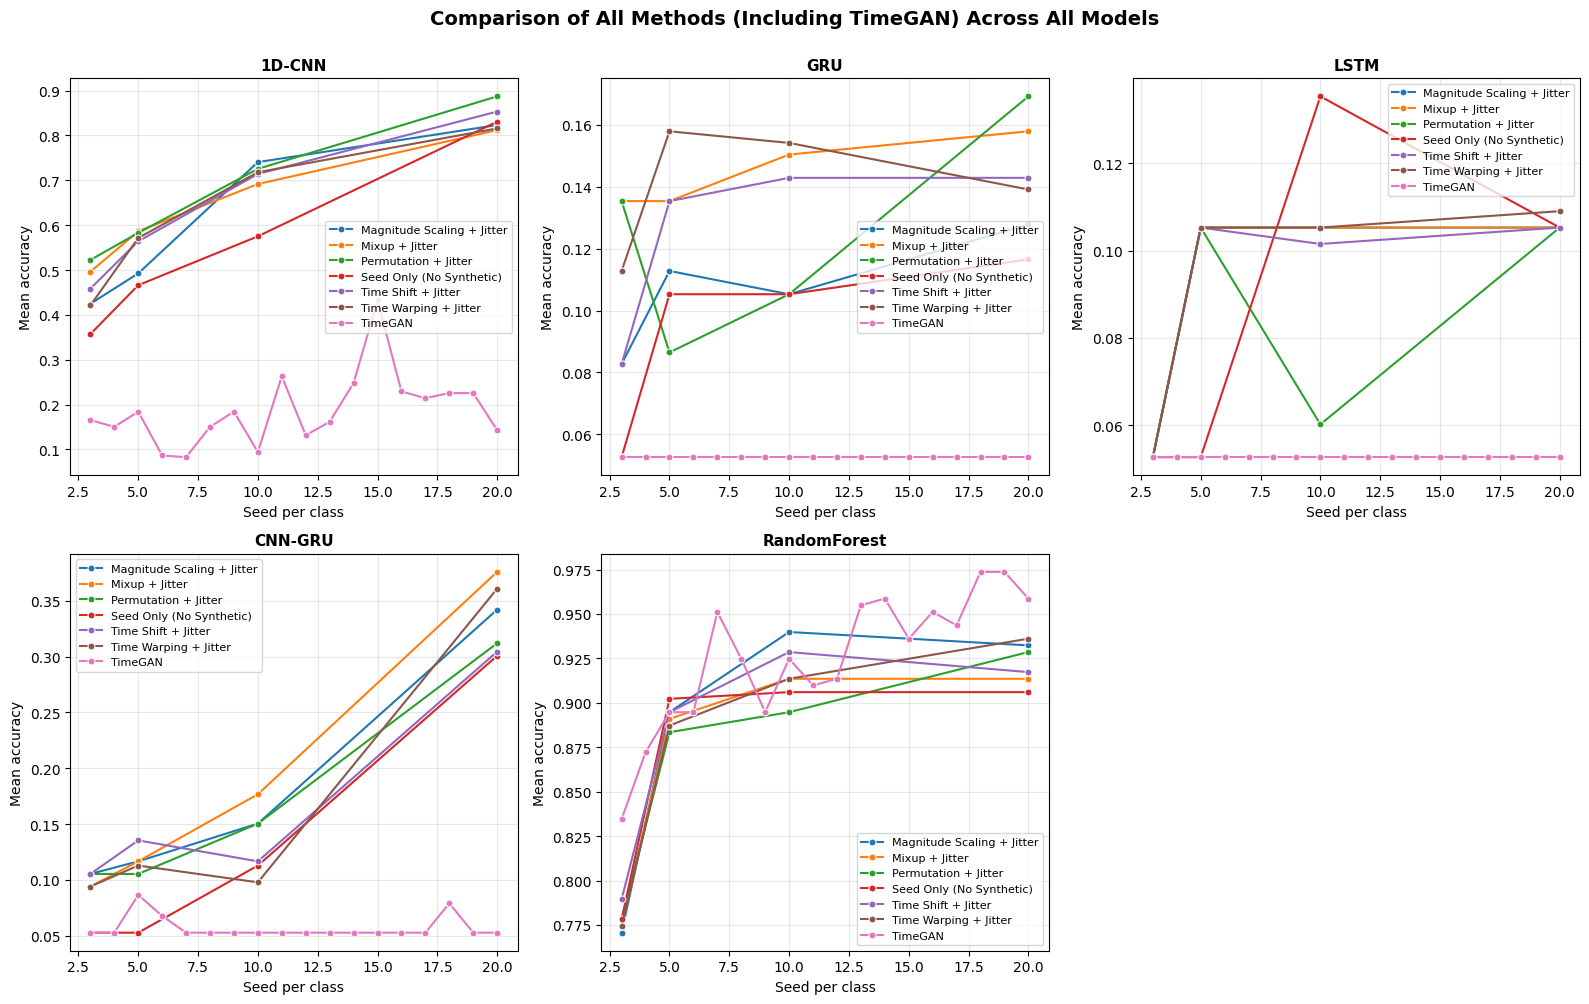


Overall Mean Accuracy by Method:
                              mean     std     min     max
method_label                                              
Mixup + Jitter              0.3895  0.3302  0.0526  0.9135
Permutation + Jitter        0.3848  0.3441  0.0526  0.9286
Time Shift + Jitter         0.3825  0.3407  0.0526  0.9286
Time Warping + Jitter       0.3820  0.3359  0.0526  0.9361
Magnitude Scaling + Jitter  0.3765  0.3409  0.0526  0.9398
Seed Only (No Synthetic)    0.3483  0.3390  0.0526  0.9060
TimeGAN                     0.2551  0.3435  0.0526  0.9737


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load existing results and TimeGAN-only results
df_methods = pd.read_csv("processed_timegan/seed_only_vs_generation_methods_detailed.csv")
df_timegan = pd.read_csv("processed_timegan/timegan_only_results.csv")

# Combine datasets
df_combined = pd.concat([df_methods, df_timegan], ignore_index=True, sort=False)

# Get all unique models
models = df_combined["model"].unique()
print(f"Models in dataset: {models}\n")

# Create subplots for each model
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model in enumerate(models):
    df_plot = df_combined[df_combined["model"] == model]
    df_summary = df_plot.groupby(["method_label", "seed_per_class"], as_index=False)["accuracy"].mean()
    
    # Plot on subplot
    sns.lineplot(data=df_summary, x="seed_per_class", y="accuracy", hue="method_label", 
                 marker="o", markersize=5, ax=axes[idx])
    axes[idx].set_xlabel("Seed per class", fontsize=10)
    axes[idx].set_ylabel("Mean accuracy", fontsize=10)
    axes[idx].set_title(f"{model}", fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=8, loc='best')

# Hide empty subplots if odd number of models
for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Comparison of All Methods (Including TimeGAN) Across All Models", 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Aggregate summary statistics
print("\nOverall Mean Accuracy by Method:")
overall_summary = df_combined.groupby("method_label")["accuracy"].agg(['mean', 'std', 'min', 'max']).round(4)
print(overall_summary.sort_values('mean', ascending=False))

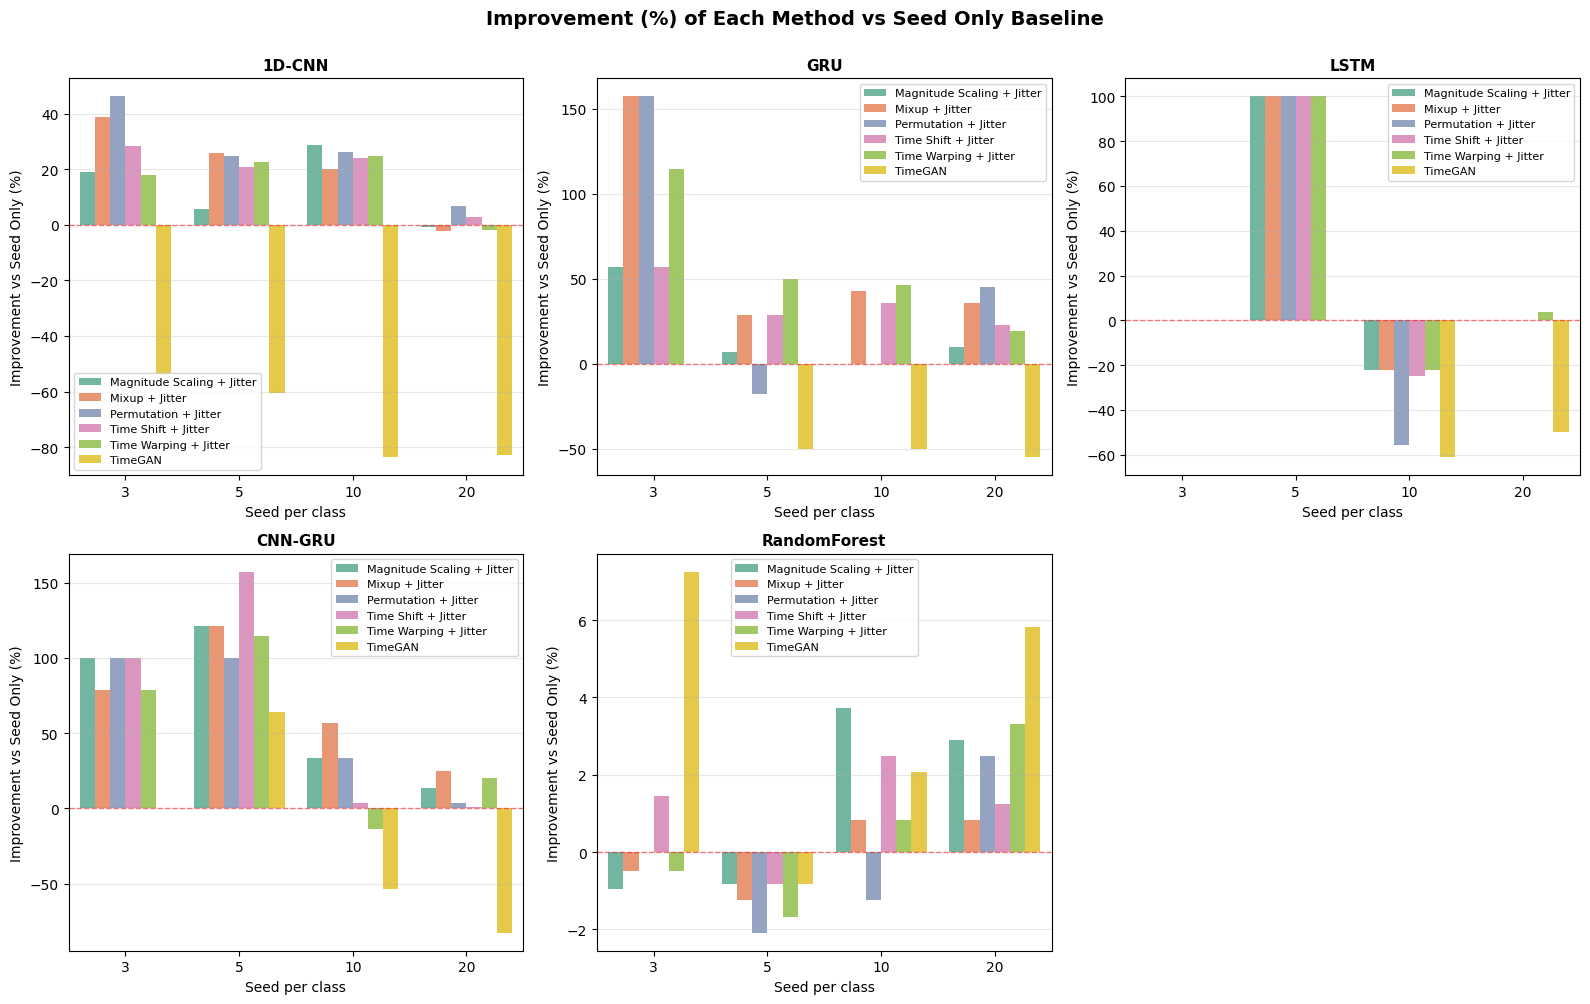


Improvement Summary (vs Seed Only):
                             mean    min     max
method                                          
Mixup + Jitter              35.31 -22.22  157.14
Time Warping + Jitter       28.82 -22.22  114.29
Permutation + Jitter        28.47 -55.56  157.14
Time Shift + Jitter         28.07 -25.00  157.14
Magnitude Scaling + Jitter  23.88 -22.22  121.43
TimeGAN                    -30.19 -83.66   64.29


In [3]:
# Calculate improvement vs Seed Only baseline
improvement_data = []

for seed_val in df_combined["seed_per_class"].unique():
    for model_val in df_combined["model"].unique():
        for method_val in df_combined[df_combined["seed_per_class"] == seed_val]["method_label"].unique():
            
            # Get accuracy for current method
            method_acc = df_combined[
                (df_combined["seed_per_class"] == seed_val) & 
                (df_combined["model"] == model_val) & 
                (df_combined["method_label"] == method_val)
            ]["accuracy"].values
            
            # Get accuracy for Seed Only baseline
            seed_only_acc = df_combined[
                (df_combined["seed_per_class"] == seed_val) & 
                (df_combined["model"] == model_val) & 
                (df_combined["method_label"] == "Seed Only (No Synthetic)")
            ]["accuracy"].values
            
            if len(method_acc) > 0 and len(seed_only_acc) > 0 and seed_only_acc[0] > 0:
                improvement_pct = ((method_acc[0] - seed_only_acc[0]) / seed_only_acc[0]) * 100
                improvement_data.append({
                    "seed_per_class": seed_val,
                    "model": model_val,
                    "method": method_val,
                    "improvement_pct": improvement_pct,
                    "baseline_acc": seed_only_acc[0]
                })

df_improvement = pd.DataFrame(improvement_data)

# Exclude Seed Only from improvement plot (its improvement is 0%)
df_improvement_filtered = df_improvement[df_improvement["method"] != "Seed Only (No Synthetic)"]

# Create subplots for improvement by model
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model in enumerate(df_combined["model"].unique()):
    df_model_imp = df_improvement_filtered[df_improvement_filtered["model"] == model]
    
    sns.barplot(data=df_model_imp, x="seed_per_class", y="improvement_pct", hue="method", 
                ax=axes[idx], palette="Set2")
    axes[idx].set_xlabel("Seed per class", fontsize=10)
    axes[idx].set_ylabel("Improvement vs Seed Only (%)", fontsize=10)
    axes[idx].set_title(f"{model}", fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].legend(fontsize=8, loc='best')

# Hide empty subplots
for idx in range(len(df_combined["model"].unique()), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Improvement (%) of Each Method vs Seed Only Baseline", 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nImprovement Summary (vs Seed Only):")
improvement_summary = df_improvement_filtered.groupby("method")["improvement_pct"].agg(['mean', 'min', 'max']).round(2)
print(improvement_summary.sort_values('mean', ascending=False))

In [ ]:
# Export seed-only results to a separate CSV so comparisons can be file-to-file.
SELECTED_SEEDS = list(range(3, 21))
seed_only_rows = []
for seed_per_class in SELECTED_SEEDS:
    rng_local = np.random.default_rng(RANDOM_SEED + seed_per_class * 100)
    X_seed, y_seed = make_seed_subset(X_train_pool, y_train_pool, seed_per_class, rng_local)

    for model_name in MODELS_5:
        acc = train_eval_model(model_name, X_seed, y_seed, X_test_fixed, y_test_fixed, RANDOM_SEED)
        seed_only_rows.append({
            'method': 'seed_only',
            'method_label': 'Seed Only (No Synthetic)',
            'seed_per_class': seed_per_class,
            'generated_total': 0,
            'train_size': len(y_seed),
            'model': model_name,
            'accuracy': acc,
        })
        print(f'seed={seed_per_class}, model={model_name}, acc={acc:.4f}')

seed_only_df = pd.DataFrame(seed_only_rows)
seed_only_out = output_dir / 'seed_only_results.csv'
seed_only_df.to_csv(seed_only_out, index=False)
print('\nSaved seed-only results to:', seed_only_out)
print('\nMean accuracy by model:')
print(seed_only_df.groupby('model')['accuracy'].mean().sort_values(ascending=False))

seed=3, model=1D-CNN, acc=0.2481
seed=3, model=GRU, acc=0.0526
seed=3, model=LSTM, acc=0.0526
seed=3, model=CNN-GRU, acc=0.0639
seed=3, model=RandomForest, acc=0.7669
seed=5, model=1D-CNN, acc=0.3271
seed=5, model=GRU, acc=0.1128
seed=5, model=LSTM, acc=0.0526
seed=5, model=CNN-GRU, acc=0.0752
seed=5, model=RandomForest, acc=0.8647
seed=8, model=1D-CNN, acc=0.4549
seed=8, model=GRU, acc=0.1053
seed=8, model=LSTM, acc=0.0526
seed=8, model=CNN-GRU, acc=0.1466
seed=8, model=RandomForest, acc=0.8985
seed=10, model=1D-CNN, acc=0.5714
seed=10, model=GRU, acc=0.1053
seed=10, model=LSTM, acc=0.1165
seed=10, model=CNN-GRU, acc=0.1090
seed=10, model=RandomForest, acc=0.9173
seed=12, model=1D-CNN, acc=0.6729
seed=12, model=GRU, acc=0.1053
seed=12, model=LSTM, acc=0.1053
seed=12, model=CNN-GRU, acc=0.1053
seed=12, model=RandomForest, acc=0.9699
seed=15, model=1D-CNN, acc=0.8158
seed=15, model=GRU, acc=0.1278
seed=15, model=LSTM, acc=0.1053
seed=15, model=CNN-GRU, acc=0.2030
seed=15, model=RandomFo

Loaded files:
  Seed-only:           /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/seed_only_results.csv
  Generation:          /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/five_method_seed_3_20_results.csv
  TimeGAN:             /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/timegan_only_results.csv
  Conditional TimeGAN: /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/conditional_timegan_results.csv

Seed-only mean accuracy by model:
model
RandomForest    0.906485
1D-CNN          0.586936
CNN-GRU         0.139098
GRU             0.100094
LSTM            0.088346
Name: accuracy, dtype: float64

Generation mean accuracy by method and model:
method_label                model       
Time Warping + Jitter       RandomForest    0.909774
Time Shift + Jitter         RandomForest    0.904135
Mixup + Jitter              RandomForest    0.903195
Magnitude Scaling + Jitter  RandomForest 

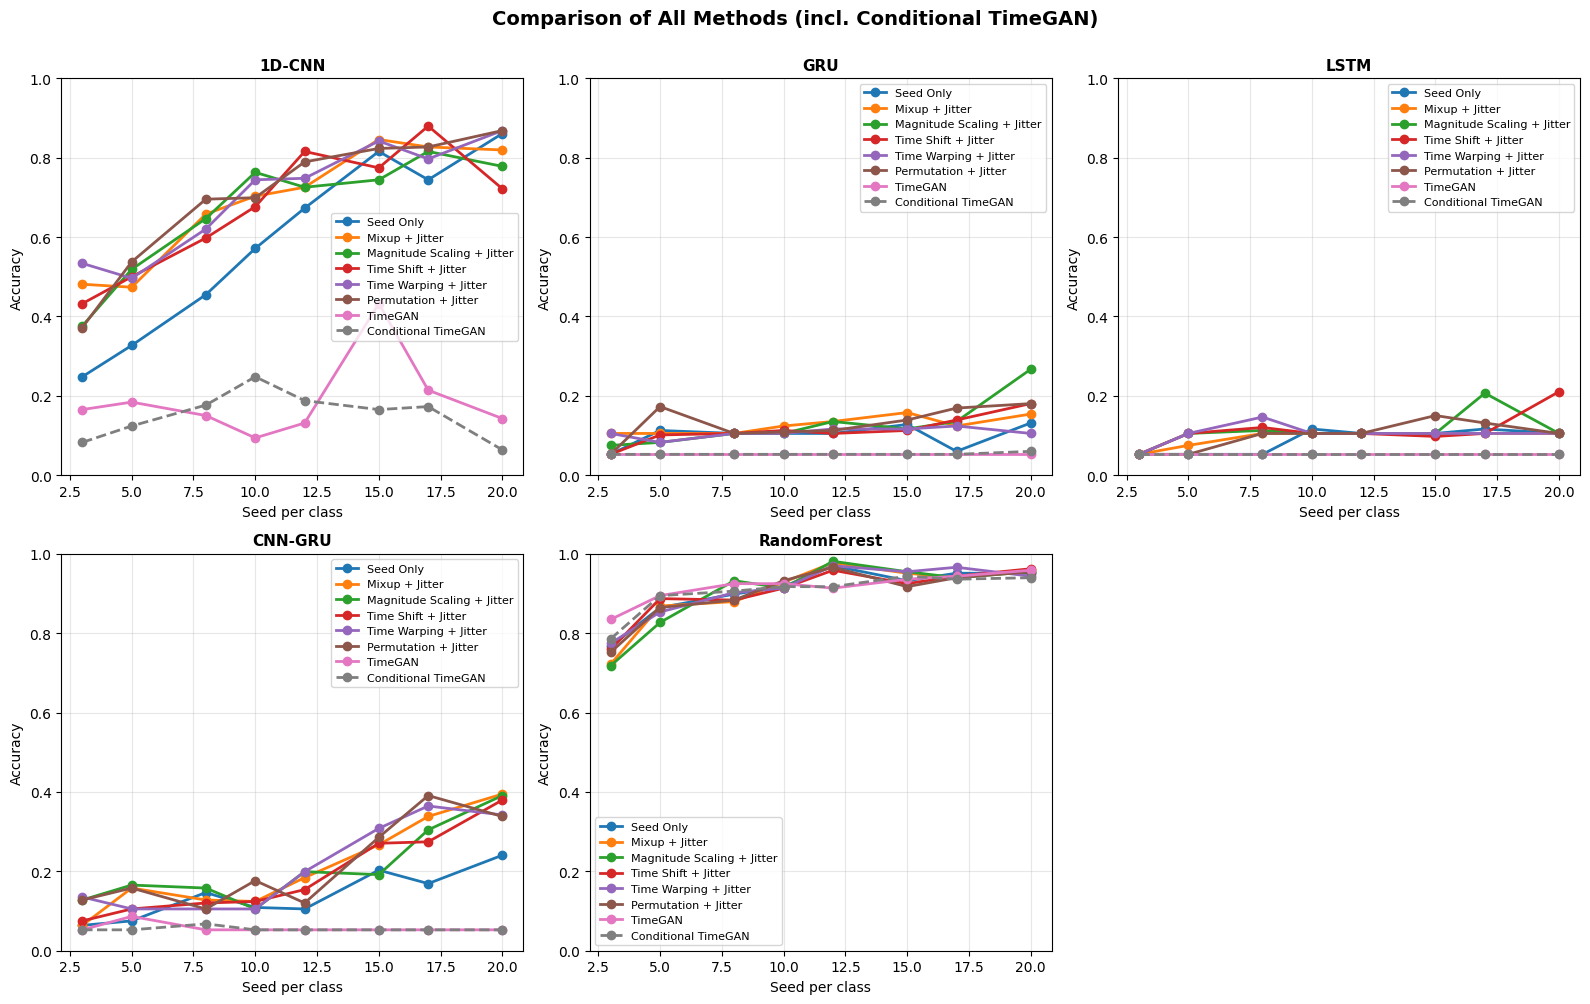

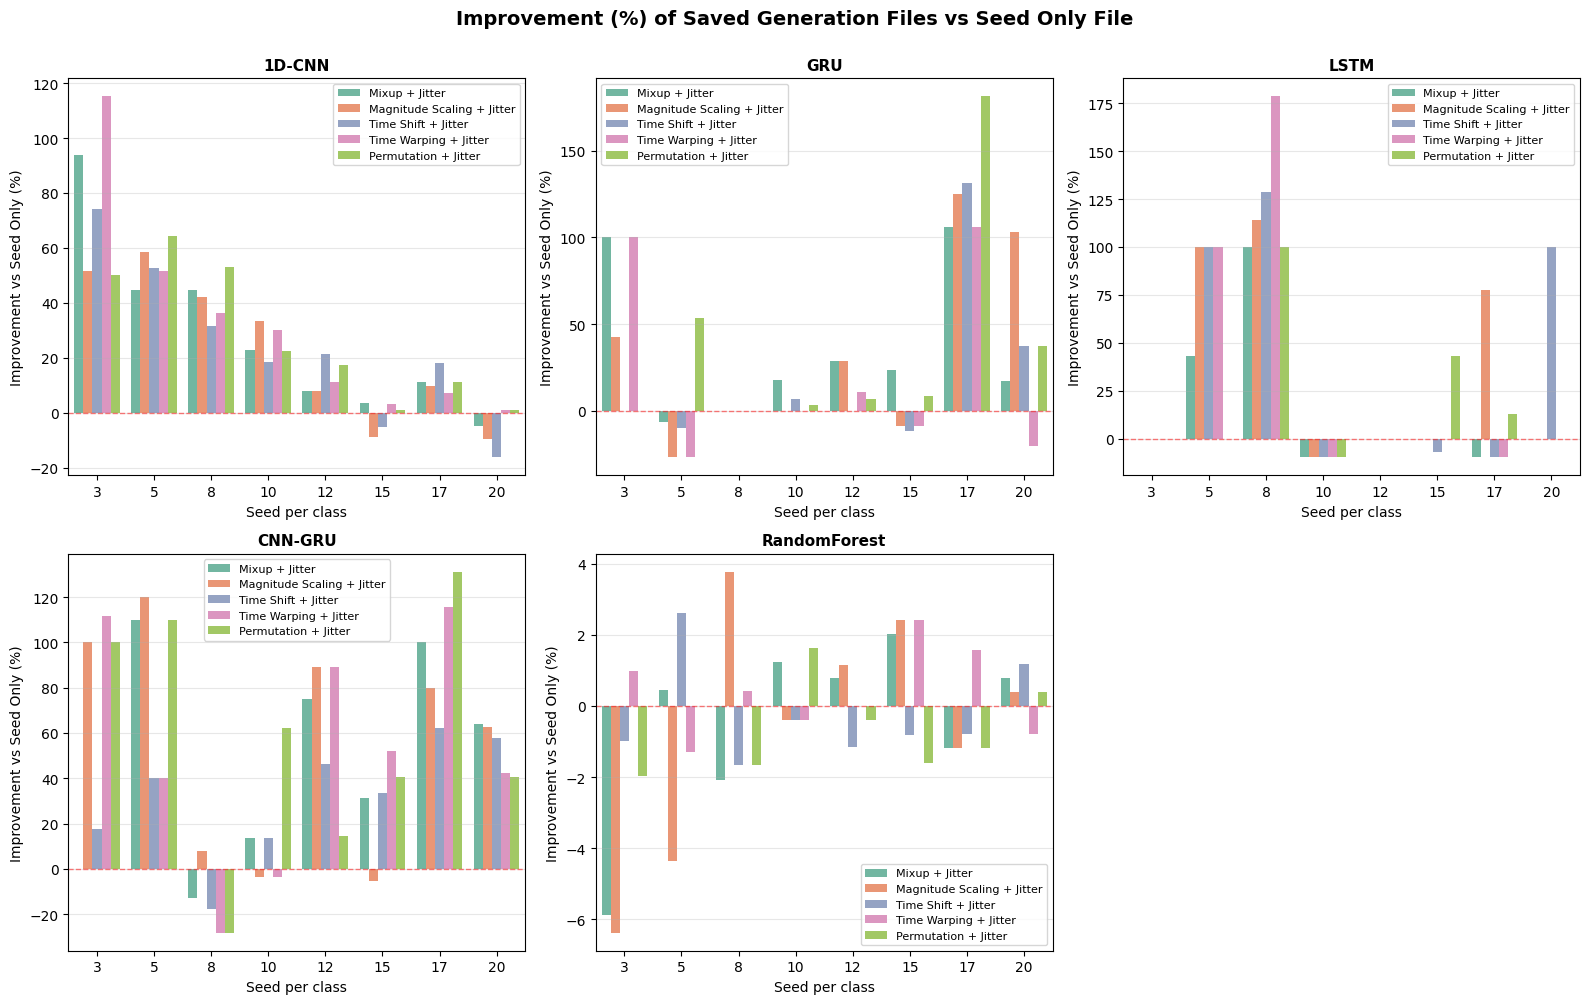

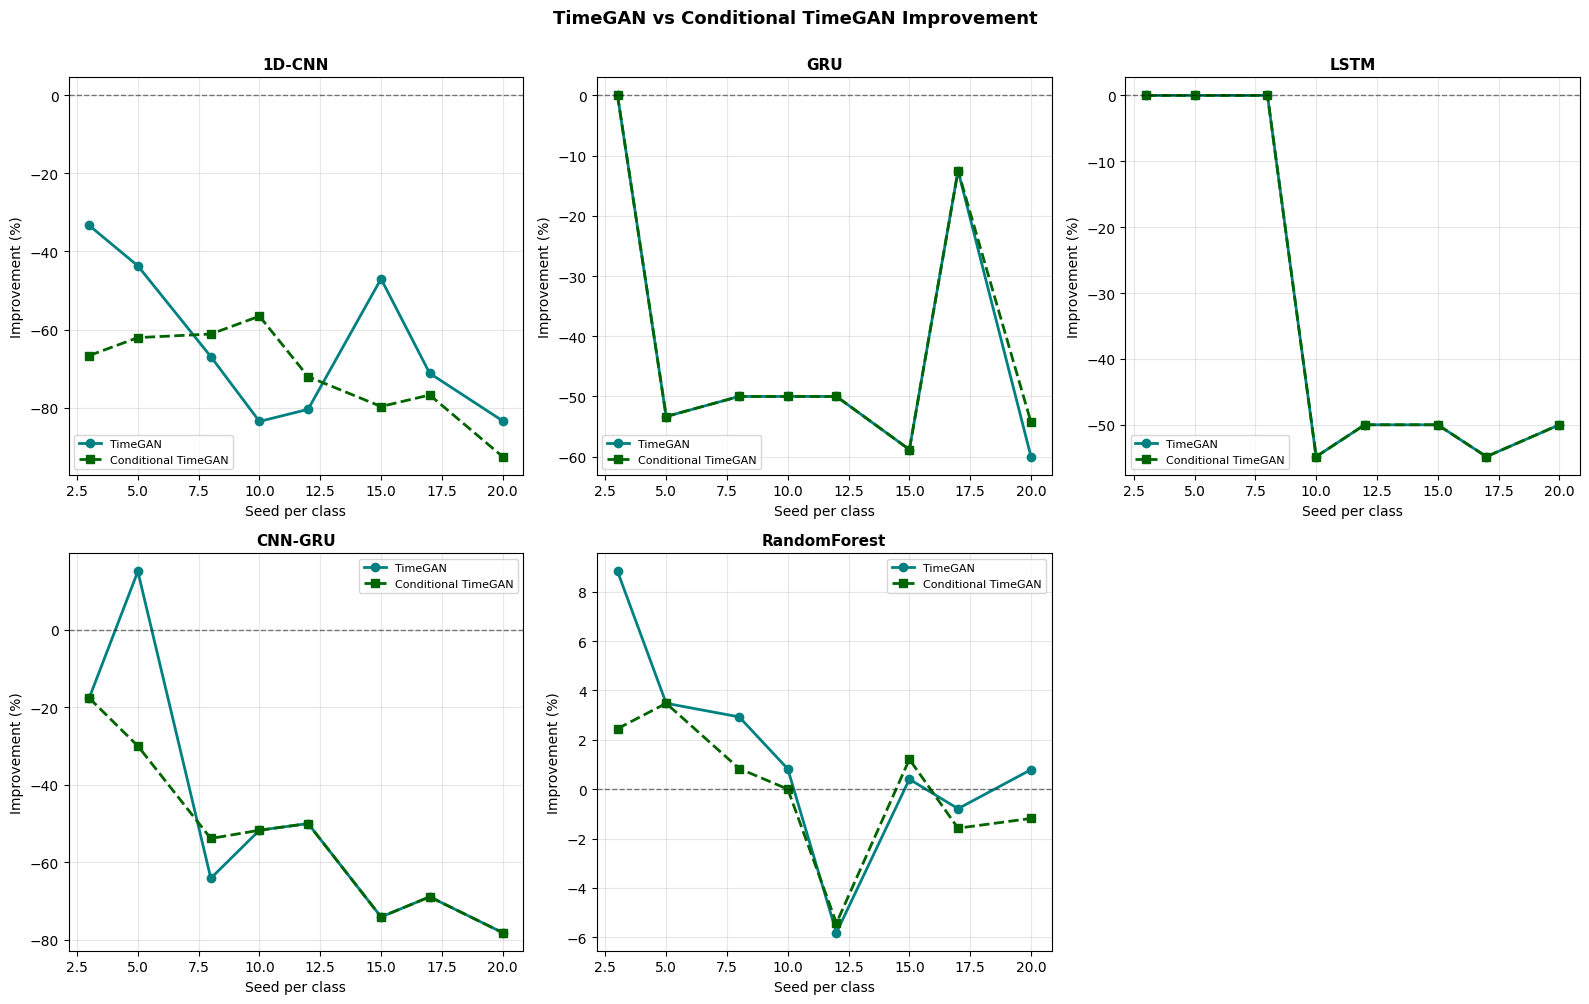


File-based improvement summary (mean %):
method_label
Magnitude Scaling + Jitter    29.42
Permutation + Jitter          28.08
Time Warping + Jitter         27.46
Mixup + Jitter                25.30
Time Shift + Jitter           22.56
Name: improvement_pct, dtype: float64

TimeGAN improvement summary (mean %):
model
RandomForest     1.33
LSTM           -32.46
GRU            -41.83
CNN-GRU        -48.70
1D-CNN         -63.70
Name: improvement_pct, dtype: float64

Conditional TimeGAN improvement summary (mean %):
model
RandomForest    -0.03
LSTM           -32.46
GRU            -41.12
CNN-GRU        -53.04
1D-CNN         -70.95
Name: improvement_pct, dtype: float64


In [ ]:
# File-based comparison only: load saved CSVs and compare results between files.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

seed_only_path = output_dir / 'seed_only_results.csv'
generation_path = output_dir / 'five_method_seed_3_20_results.csv'
timegan_path = output_dir / 'timegan_only_results.csv'
cond_timegan_path = output_dir / 'conditional_timegan_results.csv'

if not seed_only_path.exists():
    raise FileNotFoundError(f'Missing seed-only file: {seed_only_path}')
if not generation_path.exists():
    raise FileNotFoundError(f'Missing generation file: {generation_path}')
if not timegan_path.exists():
    raise FileNotFoundError(f'Missing TimeGAN file: {timegan_path}')
if not cond_timegan_path.exists():
    raise FileNotFoundError(f'Missing Conditional TimeGAN file: {cond_timegan_path}')

seed_df = pd.read_csv(seed_only_path)
gen_df = pd.read_csv(generation_path)
timegan_df = pd.read_csv(timegan_path)
cond_timegan_df = pd.read_csv(cond_timegan_path)

# Keep the requested seed grid only.
selected_seeds = list(range(3, 21))
seed_df = seed_df[seed_df['seed_per_class'].isin(selected_seeds)].copy()
gen_df = gen_df[gen_df['seed_per_class'].isin(selected_seeds)].copy()
timegan_df = timegan_df[timegan_df['seed_per_class'].isin(selected_seeds)].copy()
cond_timegan_df = cond_timegan_df[cond_timegan_df['seed_per_class'].isin(selected_seeds)].copy()

# Standardize and compare against the seed-only baseline.
seed_base = seed_df[['seed_per_class', 'model', 'accuracy']].rename(columns={'accuracy': 'seed_accuracy'})
gen_comp = gen_df[['seed_per_class', 'method_label', 'model', 'accuracy']].copy()
timegan_comp = timegan_df[['seed_per_class', 'method_label', 'model', 'accuracy']].copy()
cond_timegan_comp = cond_timegan_df[['seed_per_class', 'method_label', 'model', 'accuracy']].copy()

gen_merged = gen_comp.merge(seed_base, on=['seed_per_class', 'model'], how='left')
gen_merged['improvement_pct'] = ((gen_merged['accuracy'] - gen_merged['seed_accuracy']) / gen_merged['seed_accuracy']) * 100

timegan_merged = timegan_comp.merge(seed_base, on=['seed_per_class', 'model'], how='left')
timegan_merged['improvement_pct'] = ((timegan_merged['accuracy'] - timegan_merged['seed_accuracy']) / timegan_merged['seed_accuracy']) * 100

cond_timegan_merged = cond_timegan_comp.merge(seed_base, on=['seed_per_class', 'model'], how='left')
cond_timegan_merged['improvement_pct'] = ((cond_timegan_merged['accuracy'] - cond_timegan_merged['seed_accuracy']) / cond_timegan_merged['seed_accuracy']) * 100

print('Loaded files:')
print(f'  Seed-only:           {seed_only_path}')
print(f'  Generation:          {generation_path}')
print(f'  TimeGAN:             {timegan_path}')
print(f'  Conditional TimeGAN: {cond_timegan_path}')

print('\nSeed-only mean accuracy by model:')
print(seed_df.groupby('model')['accuracy'].mean().sort_values(ascending=False))
print('\nGeneration mean accuracy by method and model:')
print(gen_df.groupby(['method_label', 'model'])['accuracy'].mean().sort_values(ascending=False))
print('\nTimeGAN mean accuracy by model:')
print(timegan_df.groupby('model')['accuracy'].mean().sort_values(ascending=False))
print('\nConditional TimeGAN mean accuracy by model:')
print(cond_timegan_df.groupby('model')['accuracy'].mean().sort_values(ascending=False))

# Plot 1: accuracy curves by model using the files.
models = seed_df['model'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes[idx]
    seed_curve = seed_df[seed_df['model'] == model_name].sort_values('seed_per_class')
    ax.plot(seed_curve['seed_per_class'], seed_curve['accuracy'], marker='o', linewidth=2, label='Seed Only')

    gen_model = gen_df[gen_df['model'] == model_name]
    for method_label in gen_model['method_label'].unique():
        curve = gen_model[gen_model['method_label'] == method_label].groupby('seed_per_class', as_index=False)['accuracy'].mean()
        ax.plot(curve['seed_per_class'], curve['accuracy'], marker='o', linewidth=2, label=method_label)

    tg_curve = timegan_df[timegan_df['model'] == model_name].sort_values('seed_per_class')
    if not tg_curve.empty:
        ax.plot(tg_curve['seed_per_class'], tg_curve['accuracy'], marker='o', linewidth=2, label='TimeGAN')

    ctg_curve = cond_timegan_df[cond_timegan_df['model'] == model_name].sort_values('seed_per_class')
    if not ctg_curve.empty:
        ax.plot(ctg_curve['seed_per_class'], ctg_curve['accuracy'], marker='o', linewidth=2, label='Conditional TimeGAN', linestyle='--')

    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Comparison of All Methods (incl. Conditional TimeGAN)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Plot 2: improvement over the seed-only baseline.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes[idx]
    model_gen = gen_merged[gen_merged['model'] == model_name]
    sns.barplot(data=model_gen, x='seed_per_class', y='improvement_pct', hue='method_label', ax=ax, palette='Set2')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Improvement vs Seed Only (%)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8, loc='best')

for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Improvement (%) of Saved Generation Files vs Seed Only File', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Plot 3: TimeGAN and Conditional TimeGAN improvement curves.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes[idx]
    model_tg = timegan_merged[timegan_merged['model'] == model_name].sort_values('seed_per_class')
    ax.plot(model_tg['seed_per_class'], model_tg['improvement_pct'], marker='o', linewidth=2, color='teal', label='TimeGAN')
    
    model_ctg = cond_timegan_merged[cond_timegan_merged['model'] == model_name].sort_values('seed_per_class')
    ax.plot(model_ctg['seed_per_class'], model_ctg['improvement_pct'], marker='s', linewidth=2, color='darkgreen', label='Conditional TimeGAN', linestyle='--')
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Seed per class')
    ax.set_ylabel('Improvement (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('TimeGAN vs Conditional TimeGAN Improvement', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print('\nFile-based improvement summary (mean %):')
print(gen_merged.groupby('method_label')['improvement_pct'].mean().sort_values(ascending=False).round(2))
print('\nTimeGAN improvement summary (mean %):')
print(timegan_merged.groupby('model')['improvement_pct'].mean().sort_values(ascending=False).round(2))
print('\nConditional TimeGAN improvement summary (mean %):')
print(cond_timegan_merged.groupby('model')['improvement_pct'].mean().sort_values(ascending=False).round(2))

# Báo Cáo Tổng Hợp: Khảo Sát Tổng Thể Các Phương Pháp Sinh Dữ Liệu Synthetic

## I. Tóm Tắt Công Việc Đã Hoàn Thành

Notebook này thực hiện một khảo sát các phương pháp sinh dữ liệu synthetic để đánh giá tác động lên bài toán phân loại 19 loại dầu thực vật từ dữ liệu cảm biến điện tử.

### A. Kết Cấu Dữ Liệu
- Tổng cộng 1,330 chuỗi thời gian
- Mỗi chuỗi có 150 bước thời gian và 6 cảm biến TGS
- 19 lớp dầu: CO, COO, COO1-5, RO0-5, SO0-5
- Mỗi file có cùng cấu trúc 150 × 7, trong đó 1 cột thời gian và 6 cột cảm biến

### B. Chia Dữ Liệu
- 80% train, 20% test cố định cho toàn bộ thí nghiệm
- Train pool sau đó được lấy seed theo từng lớp để sinh synthetic và huấn luyện lại mô hình

### C. Tái Tạo Kết Quả
- `RANDOM_SEED = 42` được áp dụng cho `random`, `numpy`, `torch`
- MinMaxScaler được fit trên train-only để tránh leakage
- Các phép shuffle trong phần huấn luyện đã được chuyển sang RNG có seed rõ ràng

---

## II. Các Mô Hình Phân Loại

Notebook đánh giá 5 mô hình:
1. 1D-CNN
2. GRU
3. LSTM
4. CNN-GRU
5. RandomForest

Cấu hình deep model dùng chung:
- Epochs: 8
- Batch size: 32
- Optimizer: Adam
- Loss: CrossEntropyLoss

---

## III. Các Phương Pháp Sinh Dữ Liệu

### 1-5. Heuristic Augmentation
- Mixup + Jitter
- Magnitude Scaling + Jitter
- Time Shift + Jitter
- Time Warping + Jitter
- Permutation + Jitter

### 6. TimeGAN-based
- Đây là một generator kiểu TimeGAN đơn giản hóa dựa trên GRU encoder/decoder và reconstruction loss, không phải full TimeGAN nhiều thành phần như bản gốc.
- Conditional TimeGAN thêm embedding theo lớp để điều kiện hóa quá trình sinh.

---

## IV. Các Thí Nghiệm Và Seed Grid

### 1) Seed Synthetic cơ bản
- Seed per class: 3 đến 15
- Synthetic total: 50, 75, 100
- Kết quả lưu: `seed_synthetic_experiment_results.csv`
- Số đánh giá: 13 × 3 × 5 = 195

### 2) Benchmark 5 phương pháp heuristic
- Seed per class: 3 đến 20
- 5 phương pháp sinh
- Kết quả lưu: `five_method_seed_3_20_results.csv`
- Số đánh giá: 18 × 5 × 5 = 450

### 3) TimeGAN-only
- Seed per class: 3 đến 20
- Kết quả lưu: `timegan_only_results.csv`
- Số đánh giá: 18 × 5 = 90
- Trong benchmark, generator được gọi với `epochs=20`

### 4) Conditional TimeGAN
- Seed per class: 3, 5, 8, 10, 12, 15, 17, 20
- Kết quả lưu: `conditional_timegan_results.csv`
- Số đánh giá: 8 × 5 = 40
- Trong benchmark, generator được gọi với `epochs=20`

### 5) So sánh chi tiết Seed-only vs 5 phương pháp
- Seed-only chạy trên toàn bộ seed grid từ 3 đến 20
- 5 phương pháp sinh chạy trên cùng seed grid 3 đến 20
- Kết quả lưu: `seed_only_vs_generation_methods_detailed.csv`
- Số đánh giá: 18 × 6 × 5 = 540

### 6) Seed-only file riêng
- Seed per class: 3 đến 20
- Kết quả lưu: `seed_only_results.csv`
- Số đánh giá: 18 × 5 = 90

---

## V. Tổng Kết Ngắn

- RandomForest là baseline mạnh và ổn định.
- Deep models hưởng lợi rõ hơn khi thêm synthetic data.
- Mixup + Jitter thường là heuristic hiệu quả nhất.
- TimeGAN và Conditional TimeGAN trong notebook này là các biến thể đơn giản hóa, có chi phí cao hơn nhưng không phải lúc nào cũng vượt heuristic.
- Seed size ảnh hưởng mạnh đến chất lượng mô hình, đặc biệt với deep models.

---

## VI. Ghi Chú Kỹ Thuật

- Test set được cố định 20% xuyên suốt các thí nghiệm.
- Toàn bộ dữ liệu được chuẩn hóa lại theo train-only.
- Seed selection và shuffle đã được chuyển sang RNG có seed rõ ràng để giảm phụ thuộc vào global random state.
- Các file kết quả được lưu trong `processed_timegan/`.